# Clustering Urban Mobility Patterns Using Bike-Sharing Data

UCI Bike Sharing Dataset, hourly file 

The clustering unit is the **day**

| Section | Content |
|---|---|
| 1.1 - 1.4 | Cleaning, feature engineering, feature selection, exploratory analysis |
| 2.1 - 2.3 | K-Means, AGNES (three linkages), DBSCAN |
| 3 | Evaluation and method comparison |
| 4 | Cluster profiling and validation |



## 0. Setup

In [1]:
import sys, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, scipy
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_PATH = Path("hour.csv")

print("Python     ", sys.version.split()[0], f"({platform.system()} {platform.release()})")
for m in (np, pd, sklearn, scipy, mpl, sns):
    print(f"{m.__name__:<11}", m.__version__)
print("\nRANDOM_STATE =", RANDOM_STATE)

Python      3.13.7 (Windows 11)
numpy       2.4.6
pandas      3.0.3
sklearn     1.9.0
scipy       1.18.0
matplotlib  3.11.0
seaborn     0.13.2

RANDOM_STATE = 42


In [2]:
# Shared plotting style. Blue is the default series colour; the four-colour set is
# used for cluster plots and red is reserved for anomalies.
BLUE, ORANGE, AQUA, VIOLET, RED = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#d03b3b"
CLUSTER_COLOURS = [BLUE, ORANGE, AQUA, VIOLET]
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9.5, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2.0,
})

SEQ = mpl.colors.LinearSegmentedColormap.from_list(
    "seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#256abf", "#184f95"])
DIV = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#0d366b", BLUE, "#f0efec", RED, "#7d1f1f"])


## 1.1 Clean the data

-Checks for missing values, invalid values and duplicates.

-Converts the date column, and verifies that each date carries a reasonable number of hourly observations.

In [3]:
raw = pd.read_csv(DATA_PATH)
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Shape: 17,379 rows x 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


In [4]:
# Missing values, duplicates and dtypes in one pass.
print("Total NaN cells:", int(raw.isna().sum().sum()))
print("Blank / sentinel strings:",
      int(sum(raw[c].astype(str).str.strip().isin(["", "NA", "N/A", "null", "?"]).sum()
              for c in raw.columns)))
print("Fully duplicated rows      :", int(raw.duplicated().sum()))
print("Duplicate (dteday, hr) keys:", int(raw.duplicated(subset=["dteday", "hr"]).sum()))
print("Duplicate instant ids      :", int(raw["instant"].duplicated().sum()))

Total NaN cells: 0
Blank / sentinel strings: 0
Fully duplicated rows      : 0
Duplicate (dteday, hr) keys: 0
Duplicate instant ids      : 0


In [5]:
# Date conversion, then check the calendar is contiguous and the supplied weekday agrees
# with the true day of week (the dataset encodes Sunday as 0, pandas uses Monday as 0).
df = raw.copy()
df["dteday"] = pd.to_datetime(df["dteday"], format="%Y-%m-%d")
df["timestamp"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

calendar = pd.date_range(df.dteday.min(), df.dteday.max(), freq="D")
DAY_ATTRS = ["season", "yr", "mnth", "holiday", "weekday", "workingday"]

print(f"Range {df.dteday.min().date()} to {df.dteday.max().date()}, "
      f"{df.dteday.nunique()} distinct dates")
print("Calendar days with no rows :", len(set(calendar) - set(df.dteday.unique())))
print("weekday matches true dow   :", bool((df.weekday == (df.dteday.dt.dayofweek + 1) % 7).all()))
print("Day attributes constant within each day:",
      bool((df.groupby("dteday")[DAY_ATTRS].nunique() == 1).all().all()))

Range 2011-01-01 to 2012-12-31, 731 distinct dates
Calendar days with no rows : 0
weekday matches true dow   : True
Day attributes constant within each day: True


In [6]:
# Domain checks plus the internal accounting identity.
DOMAIN = {"season": (1, 4), "yr": (0, 1), "mnth": (1, 12), "hr": (0, 23), "holiday": (0, 1),
          "weekday": (0, 6), "workingday": (0, 1), "weathersit": (1, 4),
          "temp": (0, 1), "atemp": (0, 1), "hum": (0, 1), "windspeed": (0, 1)}
out_of_range = {c: int(((df[c] < lo) | (df[c] > hi)).sum()) for c, (lo, hi) in DOMAIN.items()}

print("Fields out of documented range:", {k: v for k, v in out_of_range.items() if v} or "none")
print("Rows where cnt != casual + registered:",
      int((df.cnt != df.casual + df.registered).sum()))
print("Negative counts:", int((df[["casual", "registered", "cnt"]] < 0).sum().sum()))
print()
print("Values worth a second look:")
print(f"  windspeed == 0        : {int((df.windspeed == 0).sum()):>5} rows "
      f"({df.windspeed.nunique()} distinct values overall, so the variable is binned)")
print(f"  weathersit == 4       : {int((df.weathersit == 4).sum()):>5} rows")
print(f"  atemp == 0            : {int((df.atemp == 0).sum()):>5} rows")
print(f"  hum == 0              : {int((df.hum == 0).sum()):>5} rows on "
      f"{df.loc[df.hum == 0, 'dteday'].dt.date.nunique()} date(s)")

Fields out of documented range: none
Rows where cnt != casual + registered: 0
Negative counts: 0

Values worth a second look:
  windspeed == 0        :  2180 rows (30 distinct values overall, so the variable is binned)
  weathersit == 4       :     3 rows
  atemp == 0            :     2 rows
  hum == 0              :    22 rows on 1 date(s)


Zero wind speed is the lowest bin of a discretised variable, not a missing marker, and
`weathersit = 4` and `atemp = 0` are rare but physically consistent. All three are kept.

The zero-humidity readings are different: they fall entirely on 2011-03-10, where every recorded
hour reports 0 % relative humidity. That is not physically possible, so it is treated as a sensor
fault.

In [7]:
bad_day = df.loc[df.hum == 0, "dteday"].iloc[0]
print(f"{bad_day.date()}: {int((df.dteday == bad_day).sum())} hours recorded, "
      f"all reporting 0% humidity")
print("Adjacent-day mean humidity:")
print(df[df.dteday.isin([bad_day - pd.Timedelta(days=1), bad_day + pd.Timedelta(days=1)])]
      .groupby("dteday").hum.mean().round(4).to_string())

2011-03-10: 22 hours recorded, all reporting 0% humidity
Adjacent-day mean humidity:
dteday
2011-03-09   0.7754
2011-03-11   0.6496


### Hourly coverage per day

The clustering unit is the day, so each date needs enough hours to be trustworthy.

In [8]:
hours_per_day = df.groupby("dteday").size().rename("observed_hours")
n_days = len(hours_per_day)
gaps_by_hour = (n_days - df.groupby("hr").size().reindex(range(24), fill_value=0))

print(f"Expected hourly rows : {n_days * 24:,}")
print(f"Actual rows          : {len(df):,}")
print(f"Never written        : {n_days * 24 - len(df):,}\n")
print(hours_per_day.value_counts().sort_index().rename("n_days").to_frame().T.to_string())
print(f"\nGaps at 02:00-05:00: {int(gaps_by_hour.loc[2:5].sum())} of "
      f"{int(gaps_by_hour.sum())} ({gaps_by_hour.loc[2:5].sum() / gaps_by_hour.sum():.0%})")

Expected hourly rows : 17,544
Actual rows          : 17,379
Never written        : 165

observed_hours  1   8   11  12  16  17  18  22  23   24
n_days           1   1   1   1   1   1   2   6  62  655

Gaps at 02:00-05:00: 98 of 165 (59%)


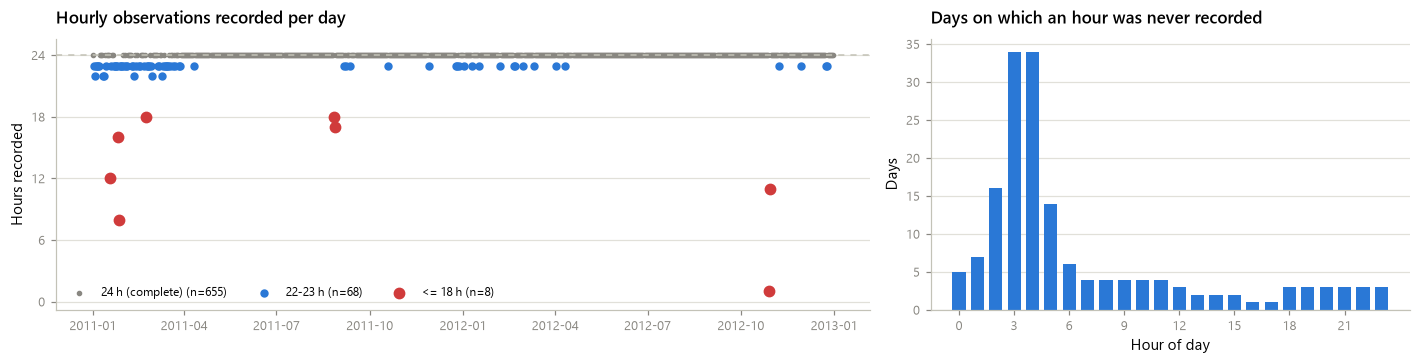

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1.7, 1]})

cov = hours_per_day.reset_index()
band = pd.cut(cov.observed_hours, [0, 18, 23, 24],
              labels=["<= 18 h", "22-23 h", "24 h (complete)"])
for lbl, colour, size in [("24 h (complete)", MUTED, 7), ("22-23 h", BLUE, 20), ("<= 18 h", RED, 45)]:
    s = cov[band == lbl]
    axes[0].scatter(s.dteday, s.observed_hours, s=size, color=colour, label=f"{lbl} (n={len(s)})")
axes[0].axhline(24, color="#c3c2b7", lw=1, ls=(0, (4, 4)))
axes[0].set_yticks([0, 6, 12, 18, 24]); axes[0].set_ylim(-0.8, 25.6)
axes[0].set_title("Hourly observations recorded per day")
axes[0].set_ylabel("Hours recorded"); axes[0].xaxis.grid(False)
axes[0].legend(loc="lower left", ncol=3, fontsize=8)

axes[1].bar(gaps_by_hour.index, gaps_by_hour.values, width=0.72, color=BLUE)
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_title("Days on which an hour was never recorded")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("Days"); axes[1].xaxis.grid(False)
plt.tight_layout(); plt.show()

The gaps concentrate between 2 and 5, which indicates that an hour with no rentals simply
produced no row rather than that data was lost.

The eight days with 18 hours or fewer are a different case, examined below.

In [10]:
def hour_blocks(hours):
    hs = sorted(hours); blocks, start, prev = [], hs[0], hs[0]
    for h in hs[1:]:
        if h != prev + 1:
            blocks.append((start, prev)); start = h
        prev = h
    blocks.append((start, prev))
    return ", ".join(f"{a:02d}-{b:02d}" if a != b else f"{a:02d}" for a, b in blocks)


severe = hours_per_day[hours_per_day < 20].index
(df[df.dteday.isin(severe)].groupby("dteday")
   .agg(hours=("hr", "size"), recorded=("hr", hour_blocks),
        total_rentals=("cnt", "sum"), worst_weather=("weathersit", "max")))

,hours,recorded,total_rentals,worst_weather
dteday,,,,
2011-01-18,12,12-23,683,2
2011-01-26,16,"00-02, 05-17",506,4
2011-01-27,8,16-23,431,1
2011-02-22,18,06-23,1450,2
2011-08-27,18,00-17,1115,3
2011-08-28,17,07-23,4334,3
2012-10-29,1,00,22,3
2012-10-30,11,13-23,1096,3


Each is a single contiguous block of hours, meaning the service ran, stopped and in some cases
restarted. All eight coincide with documented Washington D.C. weather emergencies: the January 2011
snowstorms, Hurricane Irene (August 2011) and Hurricane Sandy (October 2012). These are unusual but
valid mobility days rather than data faults, so they are kept.

### Cleaning actions

1. Repair the 2011-03-10 humidity readings using the same clock hour on the adjacent days. Time
   interpolation is not used because both surviving endpoints are overnight humidity maxima, which
   would push the daily mean above either neighbour.
2. Re-index onto the complete 731 x 24 grid with rental counts set to zero on inserted rows and
   weather left missing. This gives every day the same 24-hour denominator for the share features
   built in 1.2.
3. Record `observed_hours` per day as an audit column, excluded from the clustering features.

No observation is removed.

In [11]:
clean = df.copy().sort_values("timestamp")
clean.loc[clean.hum == 0, "hum"] = np.nan

hum_wide = (clean.set_index(["dteday", "hr"])["hum"].unstack("hr")
                 .reindex(pd.date_range(clean.dteday.min(), clean.dteday.max(), freq="D")))
neighbour_mean = (hum_wide.shift(1) + hum_wide.shift(-1)) / 2
neighbour_mean.index.name = "dteday"
clean = clean.join(neighbour_mean.stack().rename("fill"), on=["dteday", "hr"])
clean["hum"] = clean.hum.fillna(clean.fill)
clean["hum"] = (clean.set_index("timestamp").hum
                     .interpolate(method="time", limit_direction="both").to_numpy())
clean = clean.drop(columns="fill")

repaired = clean.loc[clean.dteday == "2011-03-10", "hum"].mean()
lo = clean.loc[clean.dteday == "2011-03-11", "hum"].mean()
hi = clean.loc[clean.dteday == "2011-03-09", "hum"].mean()
assert lo < repaired < hi
print(f"2011-03-10 daily mean humidity: {repaired:.4f}  (neighbours {lo:.4f} and {hi:.4f})")

2011-03-10 daily mean humidity: 0.7084  (neighbours 0.6496 and 0.7754)


In [12]:
COUNT_COLS = ["casual", "registered", "cnt"]
WEATHER_COLS = ["weathersit", "temp", "atemp", "hum", "windspeed"]

all_days = pd.date_range(clean.dteday.min(), clean.dteday.max(), freq="D")
grid = pd.MultiIndex.from_product([all_days, range(24)], names=["dteday", "hr"])

hourly = clean.drop(columns=["instant", "timestamp"]).set_index(["dteday", "hr"]).reindex(grid)
hourly["observed"] = hourly.cnt.notna()
hourly[COUNT_COLS] = hourly[COUNT_COLS].fillna(0).astype(int)
# Calendar attributes are constant within a day, so restore them from the day itself.
hourly = (hourly.drop(columns=DAY_ATTRS)
                .join(clean.groupby("dteday")[DAY_ATTRS].first(), on="dteday"))
hourly = hourly[DAY_ATTRS + WEATHER_COLS + COUNT_COLS + ["observed"]].sort_index()

day_quality = pd.DataFrame({"observed_hours": hours_per_day.reindex(all_days).fillna(0).astype(int)})
day_quality["quality_flag"] = pd.cut(day_quality.observed_hours, [-1, 18, 23, 24],
                                     labels=["severely_incomplete", "minor_gaps", "complete"])
day_quality.index.name = "dteday"

assert hourly.shape[0] == 731 * 24 and hourly.index.is_unique
assert int(hourly.cnt.sum()) == int(raw.cnt.sum())
assert bool(hourly.loc[hourly.observed, WEATHER_COLS].notna().all().all())

print(f"Grid: {hourly.shape[0]:,} rows ({int(hourly.observed.sum()):,} observed, "
      f"{int((~hourly.observed).sum())} inserted as zero)")
print(f"Total rentals unchanged: {int(hourly.cnt.sum()):,}")
print(day_quality.quality_flag.value_counts().to_string())

Grid: 17,544 rows (17,379 observed, 165 inserted as zero)
Total rentals unchanged: 3,292,679
quality_flag
complete               655
minor_gaps              68
severely_incomplete      8



## 1.2 Generate daily mobility features

One feature vector per day. An hourly record labelled `hr = h` covers [h:00, h+1:00), so the
06:00-09:00 window is hours 6-8 and the 16:00-19:00 window is hours 16-18.

Weather is converted back to physical units (degrees C, %, km/h) so that centroids and cluster
profiles stay readable without a second back-transformation.

In [13]:
MORNING_PEAK, EVENING_PEAK = [6, 7, 8], [16, 17, 18]
NIGHT_HOURS, MIDDAY_HOURS = [0, 1, 2, 3, 4, 5], [11, 12, 13, 14, 15]
OFF_PEAK = [h for h in range(24) if h not in MORNING_PEAK + EVENING_PEAK]
TEMP_MIN, TEMP_MAX, ATEMP_MIN, ATEMP_MAX, WIND_MAX = -8, 39, -16, 50, 67

cnt_wide = hourly["cnt"].unstack("hr")
day_totals = cnt_wide.sum(axis=1)
assert (day_totals > 0).all()

g = hourly.groupby(level="dteday")
obs = hourly[hourly.observed].groupby(level="dteday")   # weather over measured hours only

daily = pd.DataFrame(index=cnt_wide.index)
daily.index.name = "dteday"

daily["total_rentals"]       = day_totals
daily["mean_hourly_rentals"] = cnt_wide.mean(axis=1)
daily["max_hourly_rentals"]  = cnt_wide.max(axis=1)
daily["std_hourly_rentals"]  = cnt_wide.std(axis=1, ddof=0)   # the 24 hours are the whole day

daily["morning_peak_share"] = cnt_wide[MORNING_PEAK].sum(axis=1) / day_totals
daily["evening_peak_share"] = cnt_wide[EVENING_PEAK].sum(axis=1) / day_totals
daily["offpeak_share"]      = cnt_wide[OFF_PEAK].sum(axis=1) / day_totals
daily["night_share"]        = cnt_wide[NIGHT_HOURS].sum(axis=1) / day_totals
daily["midday_share"]       = cnt_wide[MIDDAY_HOURS].sum(axis=1) / day_totals
daily["peak_to_mean_ratio"] = daily.max_hourly_rentals / daily.mean_hourly_rentals

# Normalised Shannon entropy of the 24-hour profile: 1 = demand spread evenly, 0 = one hour only.
p = cnt_wide.div(day_totals, axis=0)
daily["hourly_entropy"] = (-(p * np.log(p.where(p > 0))).sum(axis=1) / np.log(24)).clip(0, 1) + 0.0

daily["casual_proportion"]     = g.casual.sum() / day_totals
daily["registered_proportion"] = g.registered.sum() / day_totals

daily["avg_temp_C"]        = g.temp.mean() * (TEMP_MAX - TEMP_MIN) + TEMP_MIN
daily["avg_humidity_pct"]  = g.hum.mean() * 100
daily["avg_windspeed_kmh"] = g.windspeed.mean() * WIND_MAX
daily["avg_feels_temp_C"]  = g.atemp.mean() * (ATEMP_MAX - ATEMP_MIN) + ATEMP_MIN
daily["temp_range_C"]      = (g.temp.max() - g.temp.min()) * (TEMP_MAX - TEMP_MIN)
daily["bad_weather_share"] = obs.weathersit.apply(lambda s: (s >= 3).mean())

print(f"Daily feature matrix: {daily.shape[0]} days x {daily.shape[1]} candidate features")
daily.head()

Daily feature matrix: 731 days x 19 candidate features


,total_rentals,mean_hourly_rentals,max_hourly_rentals,std_hourly_rentals,morning_peak_share,evening_peak_share,offpeak_share,night_share,midday_share,peak_to_mean_ratio,hourly_entropy,casual_proportion,registered_proportion,avg_temp_C,avg_humidity_pct,avg_windspeed_kmh,avg_feels_temp_C,temp_range_C,bad_weather_share
dteday,,,,,,,,,,,,,,,,,,,
2011-01-01,985,41.0417,110,33.5702,0.0132,0.1980,0.7888,0.1046,0.4569,2.6802,0.8892,0.3360,0.6640,8.1758,80.5833,10.7499,7.9993,12.2200,0.0833
2011-01-02,801,33.3750,93,29.3539,0.0137,0.2422,0.7441,0.0649,0.4632,2.7865,0.8686,0.1635,0.8365,9.0835,69.6087,16.6521,7.3468,11.2800,0.2174
2011-01-03,1349,56.2083,157,48.6861,0.1838,0.2891,0.5271,0.0082,0.2387,2.7932,0.8692,0.0890,0.9110,1.2291,43.7273,16.6367,-3.4993,5.6400,0.0000
2011-01-04,1562,65.0833,212,58.9243,0.1978,0.3054,0.4968,0.0090,0.2305,3.2574,0.8645,0.0691,0.9309,1.4000,59.0435,10.7398,-2.0000,8.4600,0.0000
2011-01-05,1600,66.6667,195,57.6416,0.1975,0.2800,0.5225,0.0119,0.2000,2.9250,0.8742,0.0512,0.9487,2.6670,43.6957,12.5223,-0.8682,6.5800,0.0000


In [14]:
FEATURE_DOC = pd.DataFrame([
    ("total_rentals",         "Volume",   "Required"),
    ("mean_hourly_rentals",   "Volume",   "Required"),
    ("max_hourly_rentals",    "Volume",   "Required"),
    ("std_hourly_rentals",    "Volume",   "Required"),
    ("morning_peak_share",    "Shape",    "Required"),
    ("evening_peak_share",    "Shape",    "Required"),
    ("offpeak_share",         "Shape",    "Required"),
    ("night_share",           "Shape",    "Added"),
    ("midday_share",          "Shape",    "Added"),
    ("peak_to_mean_ratio",    "Shape",    "Added"),
    ("hourly_entropy",        "Shape",    "Added"),
    ("casual_proportion",     "User mix", "Required"),
    ("registered_proportion", "User mix", "Required"),
    ("avg_temp_C",            "Weather",  "Required"),
    ("avg_humidity_pct",      "Weather",  "Required"),
    ("avg_windspeed_kmh",     "Weather",  "Required"),
    ("avg_feels_temp_C",      "Weather",  "Added"),
    ("temp_range_C",          "Weather",  "Added"),
    ("bad_weather_share",     "Weather",  "Added"),
], columns=["feature", "group", "status"])

daily = daily[FEATURE_DOC.feature.tolist()]
print(f"{(FEATURE_DOC.status == 'Required').sum()} required + "
      f"{(FEATURE_DOC.status == 'Added').sum()} added = {len(FEATURE_DOC)} candidates")
FEATURE_DOC.groupby(["group", "status"]).feature.apply(list).to_frame()

12 required + 7 added = 19 candidates


feature
group    status                                                     
Shape    Added     [night_share, midday_share, peak_to_mean_ratio...
         Required  [morning_peak_share, evening_peak_share, offpe...
User mix Required         [casual_proportion, registered_proportion]
Volume   Required  [total_rentals, mean_hourly_rentals, max_hourl...
Weather  Added     [avg_feels_temp_C, temp_range_C, bad_weather_s...
         Required  [avg_temp_C, avg_humidity_pct, avg_windspeed_kmh]

The seven additions cover behaviour the required twelve cannot express. `night_share` and
`midday_share` split the undifferentiated off-peak block; `peak_to_mean_ratio` and `hourly_entropy`
measure how concentrated demand is independently of how large it is; the three extra weather
features separate felt temperature, diurnal swing and precipitation from mean temperature.

Calendar attributes are held in a separate table and never enter the clustering input, so they can
be used as independent validation in Part 4.

In [15]:
SEASON_NAME = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
WEATHER_NAME = {1: "Clear", 2: "Mist", 3: "Light precip.", 4: "Heavy precip."}

context = g[DAY_ATTRS].first()
context["day_name"]     = context.index.day_name()
context["is_weekend"]   = context.weekday.isin([0, 6]).astype(int)
context["season_name"]  = context.season.map(SEASON_NAME)
context["weather_mode"] = obs.weathersit.agg(lambda s: int(s.mode().iloc[0]))
context["weather_name"] = context.weather_mode.map(WEATHER_NAME)
context = context.join(day_quality)

# Identities that must hold by construction.
assert np.allclose(daily.morning_peak_share + daily.evening_peak_share + daily.offpeak_share, 1)
assert np.allclose(daily.casual_proportion + daily.registered_proportion, 1)
assert int(daily.total_rentals.sum()) == int(raw.cnt.sum())
assert daily.notna().all().all() and daily.index.equals(context.index)
assert not set(daily.columns) & set(context.columns)

print(f"daily   {daily.shape}   clustering candidates")
print(f"context {context.shape}   labels, interpretation only")

daily   (731, 19)   clustering candidates
context (731, 13)   labels, interpretation only


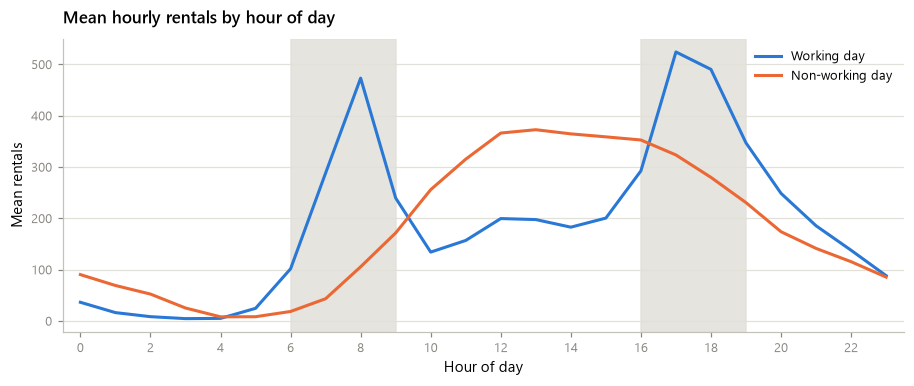

            total_rentals  morning_peak_share  midday_share  casual_proportion
workingday                                                                    
0              4,330.1690              0.0380        0.4150             0.2910
1              4,584.8200              0.1890        0.2050             0.1230


In [16]:
# Mean hourly profile by day type. This is the behavioural contrast the whole analysis rests on,
# and it confirms the peak windows chosen above.
profile = (hourly.join(context.workingday.rename("wd"), on="dteday")
                 .groupby(["wd", hourly.index.get_level_values("hr")])["cnt"].mean().unstack("wd"))

fig, ax = plt.subplots(figsize=(8.4, 3.6))
for w in MORNING_PEAK, EVENING_PEAK:
    ax.axvspan(w[0], w[-1] + 1, color=GRID, alpha=0.85, zorder=0)
ax.plot(profile.index, profile[1], color=BLUE, label="Working day")
ax.plot(profile.index, profile[0], color=ORANGE, label="Non-working day")
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
ax.set_title("Mean hourly rentals by hour of day")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean rentals")
ax.xaxis.grid(False); ax.legend()
plt.tight_layout(); plt.show()

print(daily.join(context.workingday).groupby("workingday")[
    ["total_rentals", "morning_peak_share", "midday_share", "casual_proportion"]].mean().round(3))

Working days are sharply bimodal with peaks at 08:00 and 17:00-18:00, both inside the specified
windows. Non-working days have no morning peak at all and a single broad midday plateau. The
morning-peak share differs by a factor of five between the two, while total rentals barely differ,
so the dominant structure in this data is behavioural rather than volumetric.


## 1.3 Prepare the clustering data

Distributions, then skew transformation, then redundancy removal, then scaling.

In [17]:
storm = context.quality_flag == "severely_incomplete"
SKEW_LIMIT = 0.75

# Skewness is measured twice: over all days, and excluding the eight storm days. This separates a
# genuinely asymmetric distribution from a symmetric one with a few extreme observations attached.
skew_report = pd.DataFrame({
    "skew_all": daily.skew(), "skew_excl_storm": daily[~storm].skew(),
    "kurt_all": daily.kurtosis(), "kurt_excl_storm": daily[~storm].kurtosis()})

skew_report["verdict"] = np.where(
    skew_report.skew_excl_storm.abs() > SKEW_LIMIT, "genuinely skewed",
    np.where(skew_report.skew_all.abs() > SKEW_LIMIT, "storm-driven", "symmetric"))

print(skew_report.verdict.value_counts().to_string())
skew_report.reindex(skew_report.skew_all.abs().sort_values(ascending=False).index).round(3).head(8)

verdict
symmetric           12
genuinely skewed     5
storm-driven         2


,skew_all,skew_excl_storm,kurt_all,kurt_excl_storm,verdict
peak_to_mean_ratio,17.1240,0.7180,393.0210,2.8470,storm-driven
hourly_entropy,-16.1570,-0.1640,348.6670,1.0860,storm-driven
night_share,14.3290,2.9880,293.0960,19.0810,genuinely skewed
bad_weather_share,2.6240,2.5410,7.7640,7.1240,genuinely skewed
registered_proportion,-0.9390,-0.9410,0.0880,0.0900,genuinely skewed
casual_proportion,0.9390,0.9410,0.0880,0.0900,genuinely skewed
evening_peak_share,-0.7410,-0.7720,2.6540,0.8800,genuinely skewed
offpeak_share,0.6960,0.6610,-0.9650,-1.1530,symmetric


Removing eight of 731 days takes `peak_to_mean_ratio` from +17.1 to +0.72 and `hourly_entropy` from
-16.2 to -0.16, with kurtosis falling from 393 to 2.8. Their bulk distributions are effectively
symmetric, so transforming them would only compress the storm days, which are exactly the
observations DBSCAN is expected to isolate in 2.3. They are left alone.

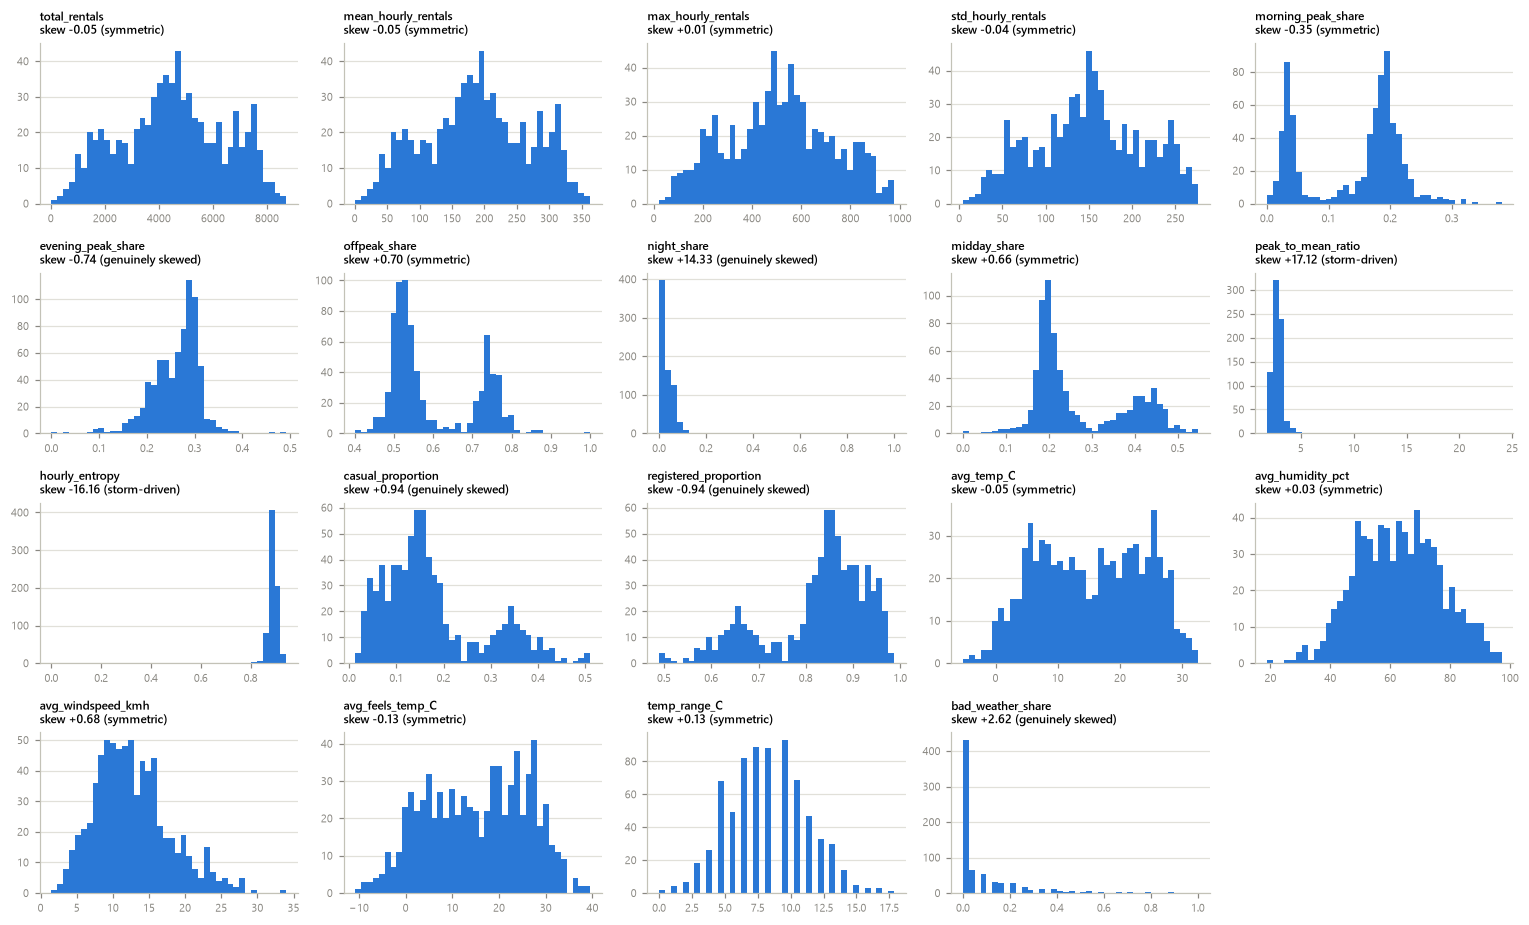

In [18]:
fig, axes = plt.subplots(4, 5, figsize=(14, 8.5))
for ax, col in zip(axes.flat, daily.columns):
    ax.hist(daily[col], bins=40, color=BLUE)
    ax.set_title(f"{col}\nskew {skew_report.loc[col, 'skew_all']:+.2f} "
                 f"({skew_report.loc[col, 'verdict']})", fontsize=8, pad=6)
    ax.tick_params(labelsize=7); ax.xaxis.grid(False)
for ax in axes.flat[len(daily.columns):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

In [19]:
# A transform is adopted only where it actually reduces |skew|. Cube root is used because it is
# monotone, defined at zero and needs no fitted parameter. (Yeo-Johnson was tried: it scores
# marginally better but fits an exponent of -28.8 for night_share, which saturates the upper tail
# so heavily that extreme days become indistinguishable from ordinary ones. It also produces an
# identical final feature set, so the simpler transform is preferred.)
candidates = skew_report.index[skew_report.verdict == "genuinely skewed"].tolist()
trial = pd.DataFrame({"before": daily.loc[~storm, candidates].skew(),
                      "after": np.cbrt(daily.loc[~storm, candidates]).skew()})
trial["applied"] = trial.after.abs() < trial.before.abs()

TRANSFORMED = trial.index[trial.applied].tolist()
TRANSFORMED_NAMES = [f"{c}_cbrt" for c in TRANSFORMED]
print(f"Cube root applied to {len(TRANSFORMED)} of {len(candidates)} candidates.")
print("(The rejected ones are skewed left, which a cube root makes worse.)\n")
trial.round(3)

Cube root applied to 3 of 5 candidates.
(The rejected ones are skewed left, which a cube root makes worse.)



,before,after,applied
evening_peak_share,-0.7720,-1.3390,False
night_share,2.9880,0.9980,True
casual_proportion,0.9410,0.1510,True
registered_proportion,-0.9410,-1.1170,False
bad_weather_share,2.5410,0.7740,True


In [20]:
features_t = daily.copy()
features_t[TRANSFORMED] = np.cbrt(daily[TRANSFORMED])
features_t = features_t.rename(columns={c: f"{c}_cbrt" for c in TRANSFORMED})

# Step 1: algebraic identities. These carry no information of their own and leave the matrix
# rank-deficient, so they go unconditionally.
identities = pd.DataFrame([
    ("mean_hourly_rentals", "total_rentals / 24",
     np.allclose(daily.mean_hourly_rentals, daily.total_rentals / 24)),
    ("offpeak_share", "1 - morning_peak_share - evening_peak_share",
     np.allclose(daily.offpeak_share, 1 - daily.morning_peak_share - daily.evening_peak_share)),
    ("registered_proportion", "1 - casual_proportion",
     np.allclose(daily.registered_proportion, 1 - daily.casual_proportion)),
], columns=["feature", "equals", "holds"])
assert identities.holds.all()
STRUCTURAL_DROPS = identities.feature.tolist()
identities

,feature,equals,holds
0,mean_hourly_rentals,total_rentals / 24,True
1,offpeak_share,1 - morning_peak_share - evening_peak_share,True
2,registered_proportion,1 - casual_proportion,True


In [21]:
from sklearn.preprocessing import StandardScaler


def vif_series(frame):
    """Variance inflation factor per column, on standardised data."""
    Xs = StandardScaler().fit_transform(frame)
    out = {}
    for i, col in enumerate(frame.columns):
        y, A = Xs[:, i], np.delete(Xs, i, axis=1)
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - ((y - A @ coef) ** 2).sum() / (y ** 2).sum()
        out[col] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


# Step 2: prune the most correlated surviving pair until every VIF is below 5. Using VIF as the
# stopping rule means the correlation threshold is not picked by hand. Ties are broken in favour
# of a specification-required feature, then by the interpretability order below.
KEEP_PREFERENCE = [
    "total_rentals", "casual_proportion_cbrt", "morning_peak_share", "evening_peak_share",
    "avg_temp_C", "avg_humidity_pct", "avg_windspeed_kmh", "hourly_entropy",
    "night_share_cbrt", "midday_share", "temp_range_C", "bad_weather_share_cbrt",
    "max_hourly_rentals", "std_hourly_rentals", "peak_to_mean_ratio", "avg_feels_temp_C"]
REQUIRED = set(FEATURE_DOC.loc[FEATURE_DOC.status == "Required", "feature"])
is_required = lambda c: c.replace("_cbrt", "") in REQUIRED

keep = [c for c in features_t.columns if c.replace("_cbrt", "") not in STRUCTURAL_DROPS]
assert set(keep) == set(KEEP_PREFERENCE)

prune_log = []
while True:
    v = vif_series(features_t[keep])
    if v.max() < 5.0:
        break
    sub = (features_t[keep].corr().abs()
           .where(np.triu(np.ones((len(keep),) * 2), 1).astype(bool)).stack())
    a, b = sub.idxmax()
    if is_required(a) != is_required(b):
        drop, why = (b, "kept the required feature") if is_required(a) else (a, "kept the required feature")
    else:
        drop = b if KEEP_PREFERENCE.index(a) < KEEP_PREFERENCE.index(b) else a
        why = "same status, kept the more interpretable"
    prune_log.append({"dropped": drop, "correlated_with": a if drop == b else b,
                      "abs_r": round(sub.max(), 4), "max_VIF_before": round(v.max(), 2),
                      "tie_break": why})
    keep.remove(drop)

SELECTED_FEATURES = keep
pd.DataFrame(prune_log)

,dropped,correlated_with,abs_r,max_VIF_before,tie_break
0,avg_feels_temp_C,avg_temp_C,0.9917,121.3100,kept the required feature
1,std_hourly_rentals,total_rentals,0.9754,119.8000,"same status, kept the more interpretable"
2,max_hourly_rentals,total_rentals,0.9307,26.4400,"same status, kept the more interpretable"
3,peak_to_mean_ratio,hourly_entropy,0.9052,14.0600,"same status, kept the more interpretable"
4,midday_share,morning_peak_share,0.8597,11.1900,kept the required feature


Selected 11 of 19 candidates
Max |r| 0.7370   Max VIF 4.52


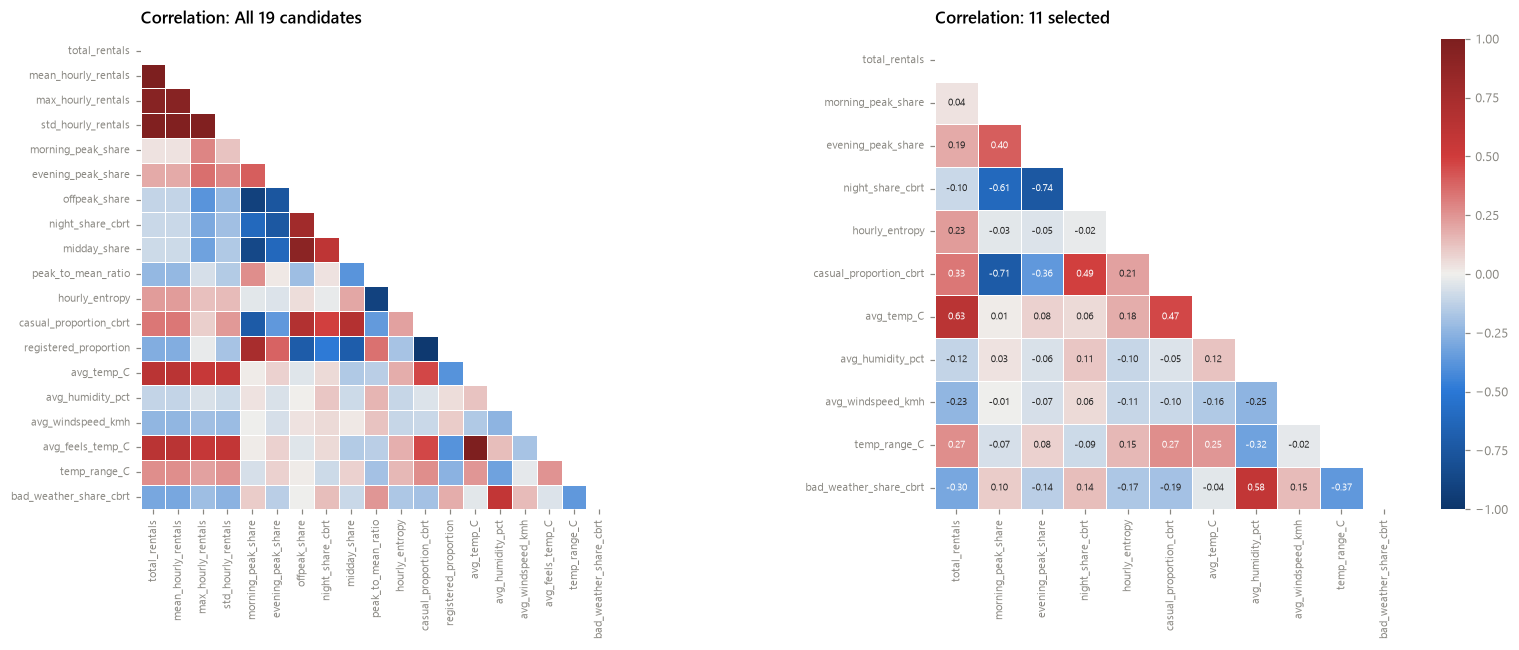

In [22]:
max_r = (features_t[SELECTED_FEATURES].corr().abs()
         .where(np.triu(np.ones((len(SELECTED_FEATURES),) * 2), 1).astype(bool)).stack().max())
print(f"Selected {len(SELECTED_FEATURES)} of {daily.shape[1]} candidates")
print(f"Max |r| {max_r:.4f}   Max VIF {vif_series(features_t[SELECTED_FEATURES]).max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cols, ttl in [(axes[0], features_t.columns, "All 19 candidates"),
                      (axes[1], SELECTED_FEATURES, f"{len(SELECTED_FEATURES)} selected")]:
    corr = features_t[list(cols)].corr()
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap=DIV, vmin=-1, vmax=1,
                center=0, square=True, ax=ax, cbar=ax is axes[1],
                annot=ax is axes[1], fmt=".2f", annot_kws={"size": 6.5},
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Correlation: {ttl}"); ax.tick_params(labelsize=7.5); ax.grid(False)
plt.tight_layout(); plt.show()

Eight features were removed: three algebraic identities and five on measured collinearity
(`avg_feels_temp_C` at r = 0.99 with temperature, `std_hourly_rentals` and `max_hourly_rentals` with
total rentals, `peak_to_mean_ratio` with entropy, `midday_share` with morning-peak share).

`total_rentals`, `std_hourly_rentals` and `max_hourly_rentals` all describe one "how busy" dimension
and the choice among them is close to arbitrary. `total_rentals` was kept because Part 2.1 and Part
4 both need interpretable values. The check below confirms the choice does not matter numerically.

In [23]:
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

alt = [c for c in SELECTED_FEATURES if c != "total_rentals"] + ["std_hourly_rentals"]
Xa = StandardScaler().fit_transform(features_t[SELECTED_FEATURES])
Xb = StandardScaler().fit_transform(features_t[alt])
print(f"Distance-matrix correlation between the two candidate sets: "
      f"{stats.pearsonr(pdist(Xa), pdist(Xb))[0]:.5f}  ({len(pdist(Xa)):,} pairs)")
print(f"Agreement of their k=4 solutions (ARI): "
      f"{adjusted_rand_score(KMeans(4, n_init=20, random_state=RANDOM_STATE).fit_predict(Xa), KMeans(4, n_init=20, random_state=RANDOM_STATE).fit_predict(Xb)):.4f}")

Distance-matrix correlation between the two candidate sets: 0.99867  (266,815 pairs)
Agreement of their k=4 solutions (ARI): 0.9542


In [24]:
# Scaling is essential: total_rentals spans 22-8,714 while morning_peak_share spans 0-0.381, and
# Euclidean distance would otherwise be almost entirely the daily total.
scaler = StandardScaler().fit(features_t[SELECTED_FEATURES])
X = scaler.transform(features_t[SELECTED_FEATURES])
X_df = pd.DataFrame(X, index=features_t.index, columns=SELECTED_FEATURES)

assert X.shape == (731, len(SELECTED_FEATURES))
assert np.allclose(X.mean(0), 0) and np.allclose(X.std(0), 1)
assert np.linalg.matrix_rank(X) == X.shape[1]
print(f"Clustering matrix X: {X.shape[0]} days x {X.shape[1]} standardised features, "
      f"rank {np.linalg.matrix_rank(X)}")

Clustering matrix X: 731 days x 11 standardised features, rank 11



## 1.4 Exploratory visualisation

Histograms and the correlation heatmap are above. This section adds boxplots by day type, the daily
rental pattern, and the two-dimensional PCA view.

PCA is used for visualisation only. All clustering in Part 2 runs on the full 11 features.

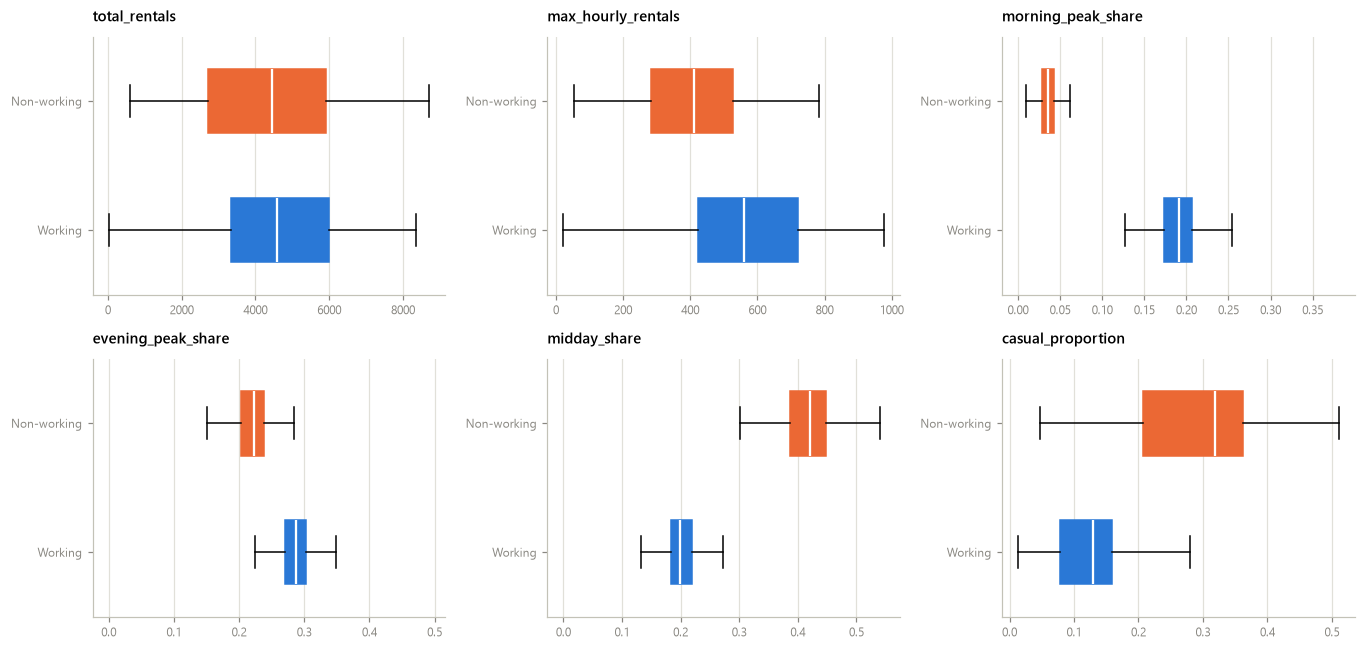

In [25]:
explore = daily.join(context)
explore["day_type"] = np.where(explore.workingday == 1, "Working day", "Non-working day")

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for ax, feat in zip(axes.flat, ["total_rentals", "max_hourly_rentals", "morning_peak_share",
                                "evening_peak_share", "midday_share", "casual_proportion"]):
    data = [explore.loc[explore.day_type == g_, feat] for g_ in ["Working day", "Non-working day"]]
    bp = ax.boxplot(data, orientation="horizontal", widths=0.5, patch_artist=True,
                    medianprops=dict(color="white", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=3, markeredgecolor="none", alpha=0.4))
    for patch, colour in zip(bp["boxes"], [BLUE, ORANGE]):
        patch.set_facecolor(colour); patch.set_edgecolor(colour)
    ax.set_yticks([1, 2]); ax.set_yticklabels(["Working", "Non-working"], fontsize=8)
    ax.set_title(feat, fontsize=9.5); ax.tick_params(labelsize=8); ax.yaxis.grid(False)
plt.tight_layout(); plt.show()

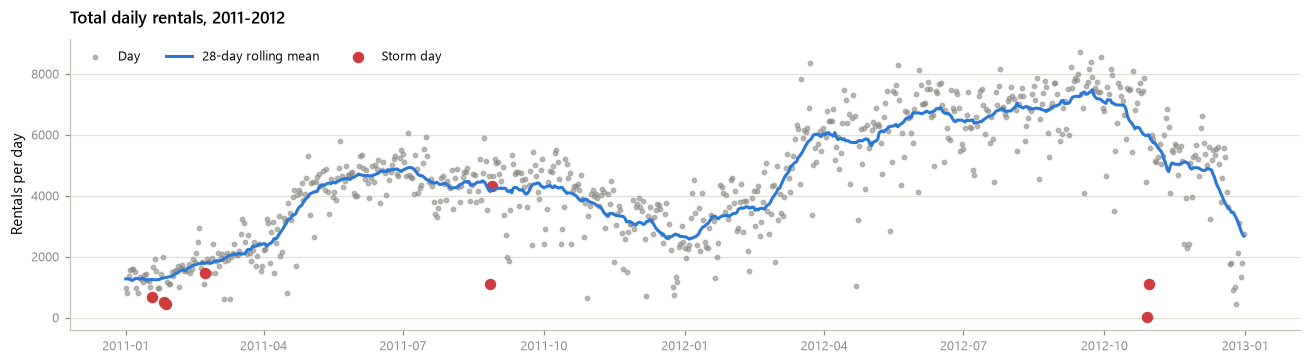

yr
0   3,406.0000
1   5,600.0000


In [26]:
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.scatter(explore.index, explore.total_rentals, s=8, color=MUTED, alpha=0.55, label="Day")
roll = explore.total_rentals.rolling(28, center=True, min_periods=7).mean()
ax.plot(roll.index, roll, color=BLUE, lw=2, label="28-day rolling mean")
st = explore[explore.quality_flag == "severely_incomplete"]
ax.scatter(st.index, st.total_rentals, s=42, color=RED, label="Storm day")
ax.set_title("Total daily rentals, 2011-2012")
ax.set_ylabel("Rentals per day"); ax.xaxis.grid(False); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

print(explore.groupby("yr").total_rentals.mean().round(0).rename("mean rentals/day").to_string())

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=len(SELECTED_FEATURES), random_state=RANDOM_STATE).fit(X)
Z = pca.transform(X)
var = pca.explained_variance_ratio_
loadings = pd.DataFrame(pca.components_[:2].T, index=SELECTED_FEATURES, columns=["PC1", "PC2"])

print(f"PC1 {var[0]:.1%}  PC2 {var[1]:.1%}  -> {var[:2].sum():.1%} in two dimensions")
print(f"Components needed for 90%: {int(np.argmax(var.cumsum() >= 0.90) + 1)}")
loadings.round(3).T

PC1 25.2%  PC2 22.4%  -> 47.6% in two dimensions
Components needed for 90%: 7


,total_rentals,morning_peak_share,evening_peak_share,night_share_cbrt,hourly_entropy,casual_proportion_cbrt,avg_temp_C,avg_humidity_pct,avg_windspeed_kmh,temp_range_C,bad_weather_share_cbrt
PC1,0.2290,-0.4460,-0.3220,0.4040,0.1790,0.5470,0.2720,-0.0730,-0.0740,0.2010,-0.1600
PC2,0.4230,0.2210,0.3870,-0.3840,0.1980,0.0170,0.2790,-0.2680,-0.1470,0.3420,-0.3840


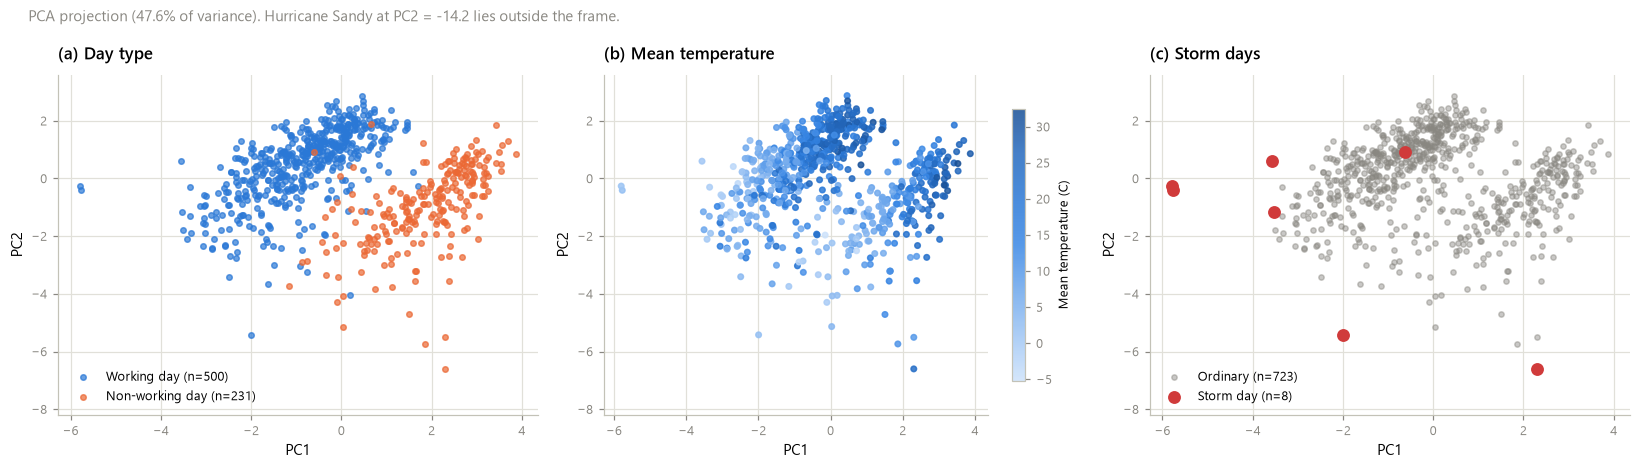

In [28]:
CLIP = (-8.2, 3.6)   # excludes only Hurricane Sandy, at PC2 = -14.2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for lbl, colour in zip(["Working day", "Non-working day"], [BLUE, ORANGE]):
    m = (explore.day_type == lbl).to_numpy()
    axes[0].scatter(Z[m, 0], Z[m, 1], s=13, color=colour, alpha=0.7, label=f"{lbl} (n={m.sum()})")
axes[0].legend(loc="lower left"); axes[0].set_title("(a) Day type")

s = axes[1].scatter(Z[:, 0], Z[:, 1], s=13, c=daily.avg_temp_C, cmap=SEQ, alpha=0.85)
fig.colorbar(s, ax=axes[1], shrink=0.8).set_label("Mean temperature (C)", fontsize=8.5)
axes[1].set_title("(b) Mean temperature")

m = (explore.quality_flag == "severely_incomplete").to_numpy()
axes[2].scatter(Z[~m, 0], Z[~m, 1], s=12, color=MUTED, alpha=0.45, label=f"Ordinary (n={(~m).sum()})")
axes[2].scatter(Z[m, 0], Z[m, 1], s=55, color=RED, label=f"Storm day (n={m.sum()})")
axes[2].legend(loc="lower left"); axes[2].set_title("(c) Storm days")

for ax in axes:
    ax.set_ylim(*CLIP); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle(f"PCA projection ({var[:2].sum():.1%} of variance). "
             f"Hurricane Sandy at PC2 = {Z[:, 1].min():.1f} lies outside the frame.",
             x=0.02, ha="left", fontsize=10, color=MUTED)
plt.tight_layout(); plt.show()

In [29]:
from sklearn.metrics import silhouette_score

for f in ["casual_proportion", "morning_peak_share", "total_rentals"]:
    print(f"  r(PC1, {f:<20}) = {stats.pearsonr(Z[:, 0], daily[f])[0]:+.3f}"
          f"   r(PC2, {f}) = {stats.pearsonr(Z[:, 1], daily[f])[0]:+.3f}")
print(f"\nSilhouette of the known working/non-working split in the full space: "
      f"{silhouette_score(X, context.workingday):.3f}")

  r(PC1, casual_proportion   ) = +0.885   r(PC2, casual_proportion) = -0.026
  r(PC1, morning_peak_share  ) = -0.743   r(PC2, morning_peak_share) = +0.347
  r(PC1, total_rentals       ) = +0.381   r(PC2, total_rentals) = +0.664

Silhouette of the known working/non-working split in the full space: 0.237


Two components capture only 47.6 % of variance, so the projection is read as suggestive rather than
as evidence.

PC1 is a commuting-leisure axis (r = +0.885 with casual proportion, -0.743 with morning-peak share,
but only +0.381 with total rentals). PC2 is a demand-and-conditions axis (r = +0.664 with total
rentals). The two vary largely independently, so at least four groups are needed to cover the
combinations.

The known working/non-working split scores a silhouette of only 0.237. That is a useful calibration
point: modest values are the realistic expectation on this data, and a much higher score would
warrant suspicion rather than confidence.


# Part 2. Clustering

All three methods use the same standardised matrix `X` (731 x 11). Results are collected in
`RESULTS` for the comparison in Part 3.

## 2.1 K-Means

In [30]:
from sklearn.metrics import (silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score)

RESULTS = {}
K_RANGE = range(2, 11)

km_models, rows = {}, []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X)
    km_models[k] = km
    sizes = np.bincount(km.labels_)
    rows.append(dict(k=k, inertia=km.inertia_,
                     silhouette=silhouette_score(X, km.labels_),
                     davies_bouldin=davies_bouldin_score(X, km.labels_),
                     calinski_harabasz=calinski_harabasz_score(X, km.labels_),
                     smallest_cluster=sizes.min()))
k_metrics = pd.DataFrame(rows).set_index("k")

# Elbow via the knee of the inertia curve: the point furthest from the chord joining its
# endpoints, with both axes min-max normalised so the result is scale free.
ks = k_metrics.index.to_numpy(float)
xn = (ks - ks.min()) / np.ptp(ks)
yn = (k_metrics.inertia - k_metrics.inertia.min()) / np.ptp(k_metrics.inertia)
k_metrics["knee_distance"] = (np.abs((xn[-1] - xn[0]) * (yn.iloc[0] - yn)
                                     - (xn[0] - xn) * (yn.iloc[-1] - yn.iloc[0]))
                              / np.hypot(xn[-1] - xn[0], yn.iloc[-1] - yn.iloc[0]))
k_metrics.round(3)

,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,knee_distance
k,,,,,,
2,"6,380.4890",0.2520,1.6910,189.7210,233,0.0000
3,"5,544.7620",0.1940,1.7070,163.8720,221,0.0950
4,"4,921.0090",0.1990,1.3030,153.6430,1,0.1440
5,"4,399.1740",0.1990,1.2800,150.2540,1,0.1700
6,"3,995.7880",0.2070,1.3790,146.7940,1,0.1710
7,"3,735.1080",0.2060,1.3630,139.1060,1,0.1400
8,"3,518.5510",0.1980,1.4170,132.7550,1,0.0990
9,"3,335.4630",0.1950,1.4270,127.3210,1,0.0510
10,"3,164.4970",0.1970,1.3300,123.4520,1,0.0000


In [31]:
# Stability: re-cluster 80% subsamples and measure agreement with the full-sample partition.
rng = np.random.default_rng(RANDOM_STATE)
stability = {}
for k in K_RANGE:
    ref, scores = km_models[k].labels_, []
    for _ in range(50):
        idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
        scores.append(adjusted_rand_score(
            ref[idx], KMeans(k, n_init=10, random_state=int(rng.integers(1e6))).fit_predict(X[idx])))
    stability[k] = (float(np.mean(scores)), float(np.std(scores)))
k_metrics["stability_ari"] = [stability[k][0] for k in K_RANGE]
k_metrics["stability_sd"] = [stability[k][1] for k in K_RANGE]

print(f"Elbow (knee)      : k = {k_metrics.knee_distance.idxmax()}")
print(f"Best silhouette   : k = {k_metrics.silhouette.idxmax()} ({k_metrics.silhouette.max():.3f})")
print(f"Best Davies-Bouldin: k = {k_metrics.davies_bouldin.idxmin()} "
      f"({k_metrics.davies_bouldin.min():.3f})")
print(f"Best Calinski     : k = {k_metrics.calinski_harabasz.idxmax()}")
k_metrics[["stability_ari", "stability_sd", "smallest_cluster"]].round(3)

Elbow (knee)      : k = 6
Best silhouette   : k = 2 (0.252)
Best Davies-Bouldin: k = 5 (1.280)
Best Calinski     : k = 2


,stability_ari,stability_sd,smallest_cluster
k,,,
2,0.9940,0.0050,233
3,0.8900,0.1200,221
4,0.8500,0.1120,1
5,0.9040,0.1020,1
6,0.8980,0.0720,1
7,0.7980,0.1340,1
8,0.8380,0.0900,1
9,0.8380,0.0670,1
10,0.8310,0.0730,1


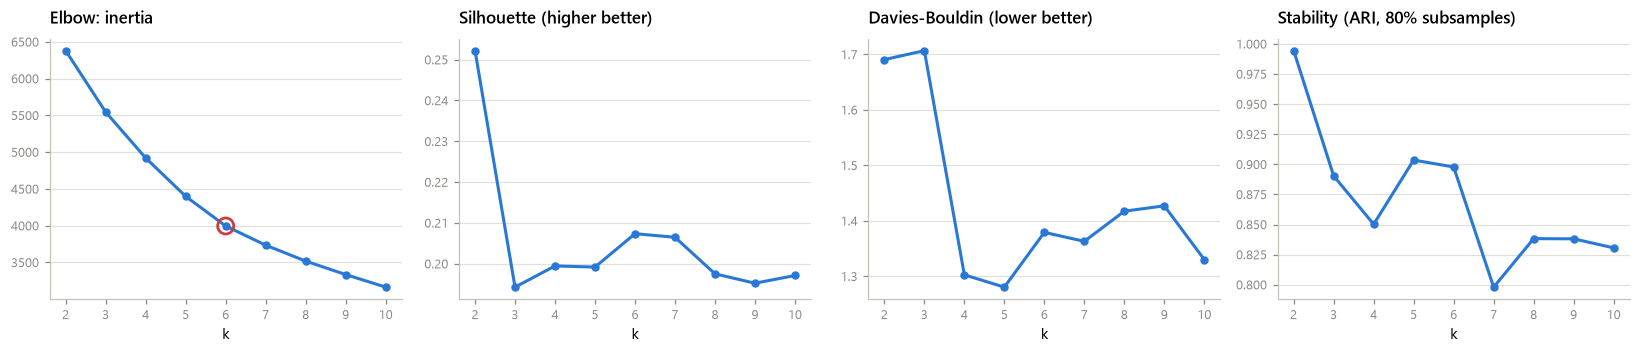

Smallest cluster by k: {2: 233, 3: 221, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1}


In [32]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, (col, ttl) in zip(axes, [("inertia", "Elbow: inertia"),
                                 ("silhouette", "Silhouette (higher better)"),
                                 ("davies_bouldin", "Davies-Bouldin (lower better)"),
                                 ("stability_ari", "Stability (ARI, 80% subsamples)")]):
    ax.plot(k_metrics.index, k_metrics[col], color=BLUE, marker="o", markersize=4.5)
    ax.set_xticks(list(K_RANGE)); ax.set_title(ttl); ax.set_xlabel("k"); ax.xaxis.grid(False)
axes[0].scatter([k_metrics.knee_distance.idxmax()],
                [k_metrics.inertia[k_metrics.knee_distance.idxmax()]],
                s=110, facecolor="none", edgecolor=RED, linewidths=1.8, zorder=5)
plt.tight_layout(); plt.show()

print("Smallest cluster by k:", k_metrics.smallest_cluster.to_dict())

The criteria disagree. Silhouette and Calinski-Harabasz favour k = 2; the knee indicates k = 6 with
k = 5 tied to within 0.0003; Davies-Bouldin is minimised at k = 5.

Two facts settle it. k = 2 is a false optimum: it reproduces the working/non-working split already
measured at silhouette 0.237, so its score of 0.252 represents no discovery. And from k = 4 onward
K-Means gives an entire cluster to a single day (Hurricane Sandy) at every k tested, which is a
property of an algorithm that must assign every point rather than an artefact of the k chosen.

k = 5 is selected: it sits in the elbow region, minimises Davies-Bouldin, and gives four substantive
clusters plus the single-day cluster.

In [33]:
KMEANS_K = 5
kmeans = km_models[KMEANS_K]

# Relabel by descending centroid demand so cluster ids do not depend on initialisation order.
order = np.argsort(-kmeans.cluster_centers_[:, SELECTED_FEATURES.index("total_rentals")])
remap = {old: new for new, old in enumerate(order)}
km_labels = np.array([remap[l] for l in kmeans.labels_])
centroids_scaled = kmeans.cluster_centers_[order]
RESULTS["K-Means (k=5)"] = km_labels

print(f"Cluster sizes: {np.bincount(km_labels).tolist()}")
print(f"Silhouette {silhouette_score(X, km_labels):.3f}   "
      f"Davies-Bouldin {davies_bouldin_score(X, km_labels):.3f}")

Cluster sizes: [247, 208, 150, 125, 1]
Silhouette 0.199   Davies-Bouldin 1.280


In [34]:
def to_original_units(rows):
    """Invert standardisation, then invert the cube root."""
    out = pd.DataFrame(scaler.inverse_transform(rows), columns=SELECTED_FEATURES)
    for c in TRANSFORMED_NAMES:
        out[c] = out[c] ** 3
    return out.rename(columns={c: c.replace("_cbrt", "") for c in out.columns})


centroids = to_original_units(centroids_scaled)
centroids.insert(0, "days", np.bincount(km_labels))
centroids.index.name = "cluster"

ORIG_NAMES = [c.replace("_cbrt", "") for c in SELECTED_FEATURES]
empirical = daily.groupby(km_labels)[ORIG_NAMES].mean()
untransformed = [c for c in ORIG_NAMES if c not in TRANSFORMED]
assert np.abs(centroids[untransformed].to_numpy() - empirical[untransformed].to_numpy()).max() < 1e-6

centroids.round(3)

,days,total_rentals,morning_peak_share,evening_peak_share,night_share,hourly_entropy,casual_proportion,avg_temp_C,avg_humidity_pct,avg_windspeed_kmh,temp_range_C,bad_weather_share
cluster,,,,,,,,,,,,
0,247,"5,867.1620",0.1810,0.2890,0.0210,0.8910,0.1540,21.8410,61.7430,11.1910,9.3660,0.0020
1,208,"4,515.9520",0.0360,0.2150,0.0600,0.8960,0.2990,15.5190,61.8460,12.5540,8.6410,0.0050
2,150,"3,448.8400",0.1870,0.2820,0.0170,0.8800,0.0780,6.5890,53.2000,14.9870,8.2090,0.0010
3,125,"3,094.5920",0.1850,0.2620,0.0260,0.8790,0.0930,12.3850,78.3010,13.4560,5.4220,0.2720
4,1,22.0000,0.0000,0.0000,1.0000,-0.0000,0.0910,12.6800,88.0000,23.9990,0.0000,1.0000


For the eight untransformed features the back-transformed centroid is exactly the arithmetic
cluster mean. For the three cube-root features it is not: cubing a mean of cube roots is biased low
where the feature is zero-inflated, which matters most for `bad_weather_share`. Both are shown
below, and the interpretation uses the arithmetic mean.

In [35]:
pd.concat({"centroid": centroids[TRANSFORMED], "cluster mean": empirical[TRANSFORMED]},
          axis=1).round(4)

centroid                                     cluster mean                                    
  night_share casual_proportion bad_weather_share  night_share casual_proportion bad_weather_share
0      0.0205            0.1540            0.0021       0.0213            0.1569            0.0273
1      0.0600            0.2989            0.0050       0.0632            0.3095            0.0531
2      0.0169            0.0776            0.0007       0.0185            0.0850            0.0211
3      0.0263            0.0926            0.2723       0.0301            0.0990            0.3151
4      1.0000            0.0909            1.0000       1.0000            0.0909            1.0000

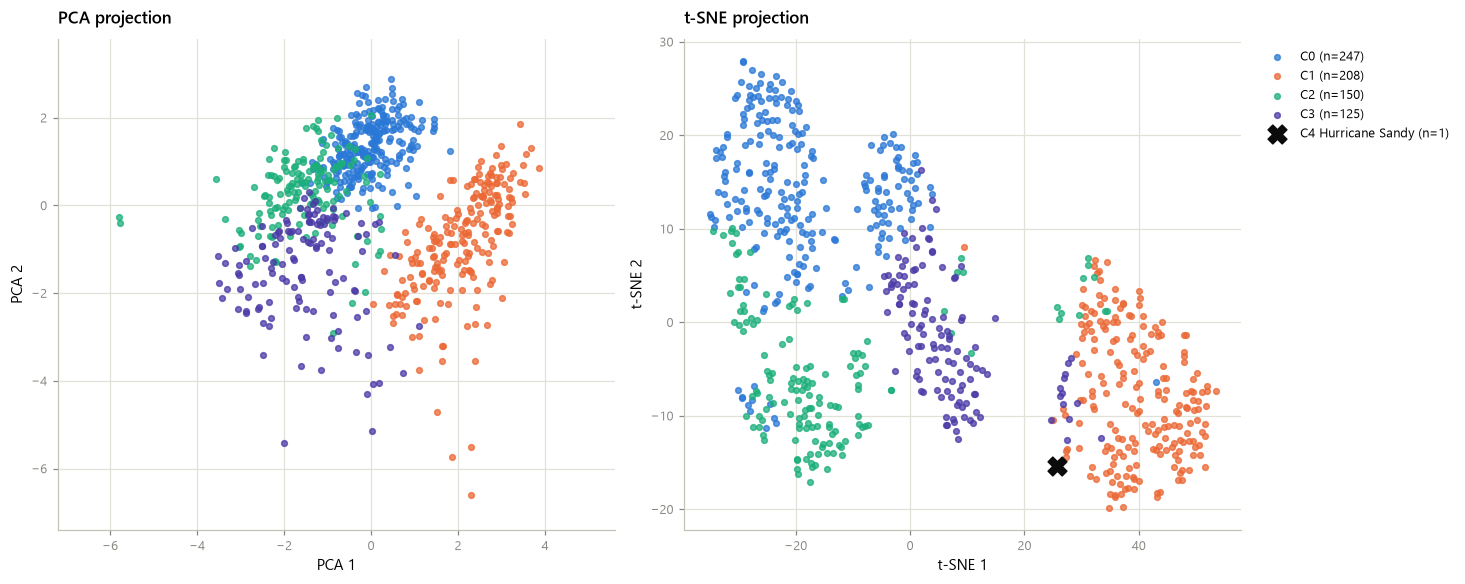

In [36]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
            random_state=RANDOM_STATE).fit_transform(X)
singleton = np.flatnonzero(np.bincount(km_labels) == 1)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.4))
for ax, coords, name in [(axes[0], Z[:, :2], "PCA"), (axes[1], tsne, "t-SNE")]:
    for c in range(KMEANS_K):
        m = km_labels == c
        if c in singleton:
            ax.scatter(coords[m, 0], coords[m, 1], s=150, marker="X", color=INK,
                       label=f"C{c} Hurricane Sandy (n=1)", zorder=6)
        else:
            ax.scatter(coords[m, 0], coords[m, 1], s=14, alpha=0.75,
                       color=CLUSTER_COLOURS[c], label=f"C{c} (n={m.sum()})")
    ax.set_title(f"{name} projection"); ax.set_xlabel(f"{name} 1"); ax.set_ylabel(f"{name} 2")
axes[0].set_xlim(-7.2, 5.6); axes[0].set_ylim(-7.4, 3.8)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout(); plt.show()

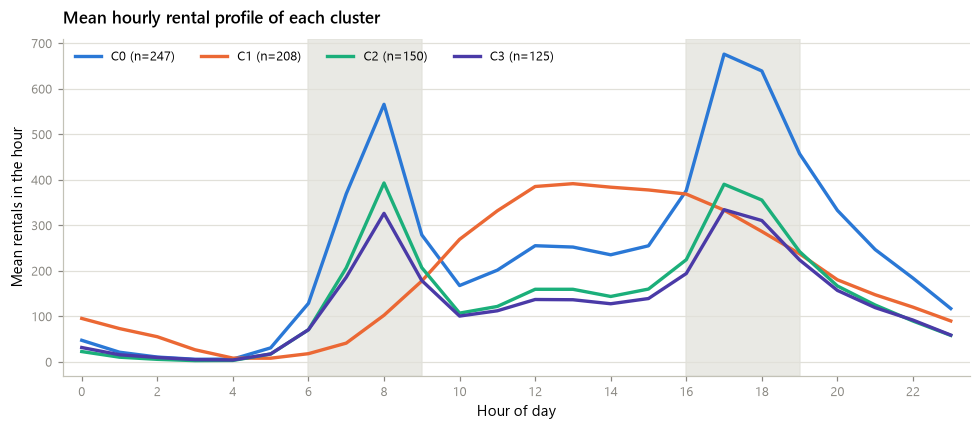

In [37]:
# Mean hourly profile per cluster: the clearest view of what separates them.
prof = hourly["cnt"].unstack("hr").groupby(km_labels).mean()

fig, ax = plt.subplots(figsize=(9, 4))
for w in MORNING_PEAK, EVENING_PEAK:
    ax.axvspan(w[0], w[-1] + 1, color=GRID, alpha=0.7, zorder=0)
for c in range(KMEANS_K):
    if c in singleton:
        continue
    ax.plot(prof.columns, prof.loc[c], color=CLUSTER_COLOURS[c], lw=2.2,
            label=f"C{c} (n={(km_labels == c).sum()})")
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
ax.set_title("Mean hourly rental profile of each cluster")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean rentals in the hour")
ax.xaxis.grid(False); ax.legend(ncol=4)
plt.tight_layout(); plt.show()

In [38]:
CLUSTER_NAMES = {
    0: "High-demand warm-season commuting",
    1: "Weekend and holiday leisure",
    2: "Cold-season clear-weather commuting",
    3: "Adverse-weather suppressed demand",
    4: "System shutdown (Hurricane Sandy)"}

# Each name has to be earned by the centroid, otherwise fail loudly.
assert centroids.loc[0, "morning_peak_share"] > 0.15 and centroids.loc[0, "avg_temp_C"] > 18
assert centroids.loc[1, "morning_peak_share"] < 0.10 and centroids.loc[1, "casual_proportion"] > 0.20
assert centroids.loc[2, "morning_peak_share"] > 0.15 and centroids.loc[2, "avg_temp_C"] < 12
assert centroids.loc[3, "bad_weather_share"] > 0.15
assert centroids.loc[4, "days"] == 1

pd.DataFrame({
    "name": pd.Series(CLUSTER_NAMES), "days": centroids.days,
    "rentals/day": centroids.total_rentals.round(0),
    "morning peak": centroids.morning_peak_share.round(3),
    "casual share": empirical.casual_proportion.round(3),
    "temp (C)": centroids.avg_temp_C.round(1),
    "bad weather": empirical.bad_weather_share.round(3)})

,name,days,rentals/day,morning peak,casual share,temp (C),bad weather
0,High-demand warm-season commuting,247,"5,867.0000",0.1810,0.1570,21.8000,0.0270
1,Weekend and holiday leisure,208,"4,516.0000",0.0360,0.3100,15.5000,0.0530
2,Cold-season clear-weather commuting,150,"3,449.0000",0.1870,0.0850,6.6000,0.0210
3,Adverse-weather suppressed demand,125,"3,095.0000",0.1850,0.0990,12.4000,0.3150
4,System shutdown (Hurricane Sandy),1,22.0000,0.0000,0.0910,12.7000,1.0000


C0 and C2 share the same twin-peak commuting shape at different volumes and temperatures. C1 has no
morning peak and a broad midday plateau, with roughly double the casual share of any other cluster.
C3 keeps the commuting shape but with demand suppressed under persistent poor weather. C4 is a
single day and is treated as an anomaly rather than a regime.


## 2.2 Hierarchical clustering (AGNES)

Single, complete and average linkage on the same matrix with Euclidean distance. The final choice
is supported by evaluation results rather than by reading the dendrograms.

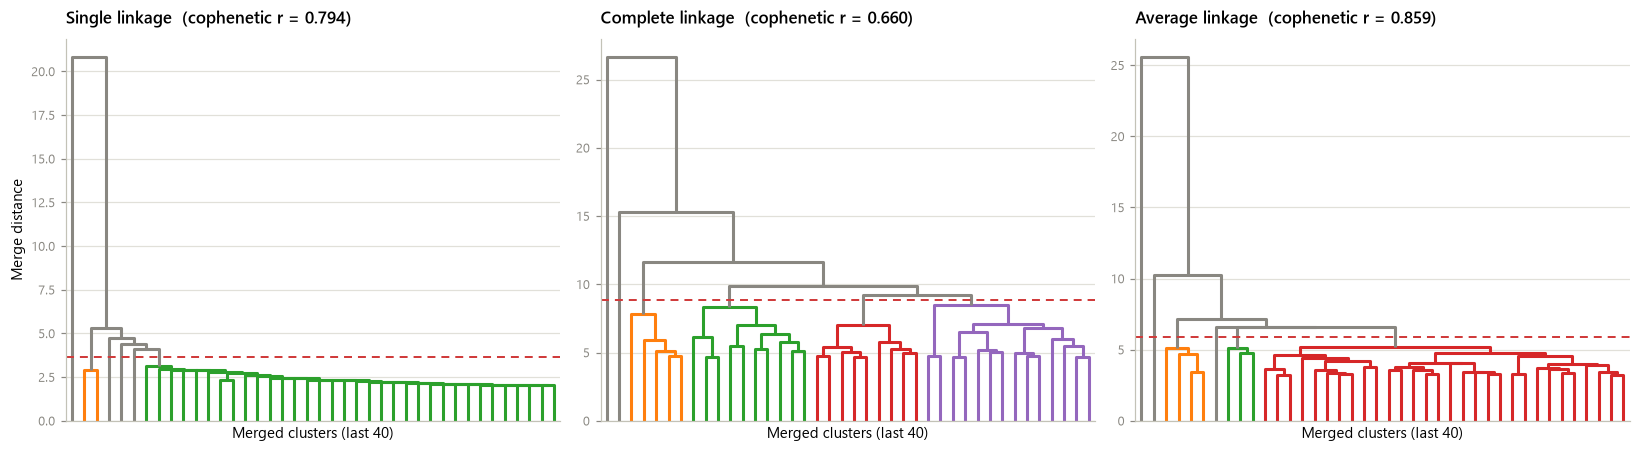

In [39]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet

D = pdist(X, metric="euclidean")
LINKAGES = ["single", "complete", "average"]
Zs = {m: linkage(D, method=m) for m in LINKAGES}


def cut_height(Zmat, k):
    return (Zmat[-k, 2] + Zmat[-(k - 1), 2]) / 2


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, m in zip(axes, LINKAGES):
    t = cut_height(Zs[m], 6)
    dendrogram(Zs[m], ax=ax, truncate_mode="lastp", p=40, color_threshold=t,
               above_threshold_color=MUTED, no_labels=True)
    ax.axhline(t, color=RED, lw=1.3, ls=(0, (4, 3)))
    ax.set_title(f"{m.capitalize()} linkage  (cophenetic r = {cophenet(Zs[m], D)[0]:.3f})")
    ax.set_xlabel("Merged clusters (last 40)"); ax.xaxis.grid(False)
axes[0].set_ylabel("Merge distance")
plt.tight_layout(); plt.show()

Cophenetic correlation ranks the linkages average (0.859) > single (0.794) > complete (0.660). That
measures how faithfully the tree reproduces the distance matrix, not whether the resulting partition
is useful, and as the cuts below show the ranking is close to the reverse of usefulness.

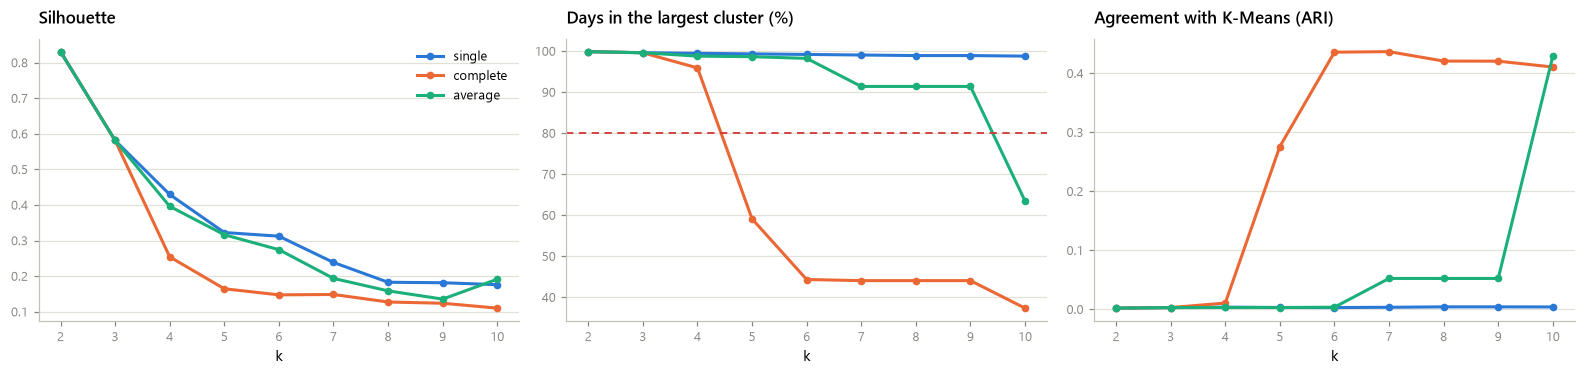

  single    usable cuts (largest < 80%, at most one singleton): none
  complete  usable cuts (largest < 80%, at most one singleton): [5, 6, 7, 8, 9, 10]
  average   usable cuts (largest < 80%, at most one singleton): none


In [40]:
# Alongside the internal indices, two structural diagnostics are recorded: how much of the data
# sits in the largest cluster, and how many singletons the cut produces.
cut_rows = []
for m in LINKAGES:
    for k in range(2, 11):
        lab = fcluster(Zs[m], k, criterion="maxclust")
        sizes = np.bincount(lab)[1:]
        cut_rows.append(dict(linkage=m, k=k,
                             silhouette=silhouette_score(X, lab),
                             davies_bouldin=davies_bouldin_score(X, lab),
                             largest_pct=100 * sizes.max() / len(X),
                             n_singletons=int((sizes == 1).sum()),
                             ari_vs_kmeans=adjusted_rand_score(km_labels, lab)))
cuts = pd.DataFrame(cut_rows)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.5))
for ax, (col, ttl) in zip(axes, [("silhouette", "Silhouette"),
                                 ("largest_pct", "Days in the largest cluster (%)"),
                                 ("ari_vs_kmeans", "Agreement with K-Means (ARI)")]):
    for m, colour in zip(LINKAGES, [BLUE, ORANGE, AQUA]):
        s = cuts[cuts.linkage == m]
        ax.plot(s.k, s[col], color=colour, marker="o", markersize=4, label=m)
    ax.set_xticks(range(2, 11)); ax.set_title(ttl); ax.set_xlabel("k"); ax.xaxis.grid(False)
axes[1].axhline(80, color=RED, lw=1.2, ls=(0, (4, 3)))
axes[0].legend()
plt.tight_layout(); plt.show()

usable = cuts[(cuts.largest_pct < 80) & (cuts.n_singletons <= 1)]
for m in LINKAGES:
    ks_ = sorted(usable.loc[usable.linkage == m, "k"].tolist())
    print(f"  {m:9s} usable cuts (largest < 80%, at most one singleton): "
          f"{ks_ if ks_ else 'none'}")

At k = 2 all three linkages return the identical partition of 730 days plus Hurricane Sandy, with a
silhouette of 0.831 and Davies-Bouldin of 0.411. Those are the best values obtained anywhere in this
study, for a result that describes nothing.

Single linkage never escapes the chaining effect: at k = 10 the largest cluster still holds 722 of
731 days, and the nine isolated points are mostly storm days, so it behaves as an outlier detector.
Average linkage is the same failure more slowly. Only complete linkage, which penalises cluster
diameter, produces a usable partition.

In [41]:
single10 = fcluster(Zs["single"], 10, criterion="maxclust")
print(f"Single linkage at k=10, sizes: {sorted(np.bincount(single10)[1:].tolist(), reverse=True)}")
peeled = [daily.index[i].date() for i in np.flatnonzero(single10 != np.bincount(single10)[1:].argmax() + 1)]
print("Isolated days:", [str(d) for d in peeled])
print("Of which flagged severely_incomplete:",
      int(storm.to_numpy()[[daily.index.get_loc(pd.Timestamp(d)) for d in peeled]].sum()))

Single linkage at k=10, sizes: [722, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Isolated days: ['2011-01-18', '2011-01-27', '2011-02-22', '2011-03-06', '2011-08-27', '2011-08-28', '2012-10-29', '2012-10-30', '2012-12-26']
Of which flagged severely_incomplete: 7


In [42]:
# Choosing the cut for complete linkage. Metrics are computed over substantive clusters (>=10 days)
# so that the micro-clusters every cut produces do not drive the comparison.
comp = []
for k in range(4, 11):
    lab = fcluster(Zs["complete"], k, criterion="maxclust")
    sizes = np.bincount(lab)
    big = [c for c in np.unique(lab) if sizes[c] >= 10]
    m_ = np.isin(lab, big)
    comp.append(dict(k=k, n_substantive=len(big),
                     silhouette=silhouette_score(X[m_], lab[m_]),
                     davies_bouldin=davies_bouldin_score(X[m_], lab[m_]),
                     calinski=calinski_harabasz_score(X[m_], lab[m_]),
                     ari_vs_kmeans=adjusted_rand_score(km_labels, lab)))
pd.DataFrame(comp).set_index("k").round(3)

,n_substantive,silhouette,davies_bouldin,calinski,ari_vs_kmeans
k,,,,,
4,2,0.2540,1.3780,46.7780,0.0110
5,3,0.1640,1.7650,109.8760,0.2760
6,4,0.1460,1.7610,110.9100,0.4360
7,4,0.1470,1.7540,112.1840,0.4370
8,5,0.1260,1.7150,93.0200,0.4210
9,5,0.1240,1.7160,91.1550,0.4210
10,6,0.1100,1.7750,83.2520,0.4110


k = 5 and k = 6 are metrically indistinguishable (Davies-Bouldin 1.765 against 1.761, Calinski
109.9 against 110.9, silhouette marginally favouring k = 5). The tie is broken by external
agreement: agreement with the independently derived K-Means solution rises from 0.276 to 0.436 at
k = 6. Convergence between two algorithms with different objectives is evidence about the data, and
is not something dendrogram inspection could show.

In [43]:
AGNES_K = 6
agnes_raw = fcluster(Zs["complete"], AGNES_K, criterion="maxclust") - 1
order_ag = np.argsort(-np.bincount(agnes_raw))
remap_ag = {old: new for new, old in enumerate(order_ag)}
agnes_labels = np.array([remap_ag[l] for l in agnes_raw])

for m in LINKAGES:
    RESULTS[f"AGNES {m} (k={AGNES_K})"] = fcluster(Zs[m], AGNES_K, criterion="maxclust") - 1
RESULTS[f"AGNES complete (k={AGNES_K})"] = agnes_labels

print(f"Complete linkage at k={AGNES_K}: sizes {np.bincount(agnes_labels).tolist()}")
print(f"Silhouette {silhouette_score(X, agnes_labels):.3f}   "
      f"Davies-Bouldin {davies_bouldin_score(X, agnes_labels):.3f}   "
      f"ARI vs K-Means {adjusted_rand_score(km_labels, agnes_labels):.3f}")

ag_prof = daily.groupby(agnes_labels)[["total_rentals", "morning_peak_share",
                                       "casual_proportion", "avg_temp_C",
                                       "avg_humidity_pct", "bad_weather_share"]].mean()
ag_prof.insert(0, "days", np.bincount(agnes_labels))
ag_prof["working_day_%"] = (context.groupby(agnes_labels).workingday.mean() * 100).round(1)
ag_prof.round(3)

Complete linkage at k=6: sizes [324, 269, 108, 27, 2, 1]
Silhouette 0.147   Davies-Bouldin 1.263   ARI vs K-Means 0.436


,days,total_rentals,morning_peak_share,casual_proportion,avg_temp_C,avg_humidity_pct,bad_weather_share,working_day_%
0,324,"4,948.3580",0.1860,0.1220,14.6180,59.1440,0.0370,98.8000
1,269,"4,737.0630",0.0730,0.2730,17.7210,59.1400,0.0270,25.7000
2,108,"3,271.5930",0.2050,0.0970,12.9490,78.5580,0.2930,99.1000
3,27,"2,247.1480",0.0480,0.1810,9.4180,80.4270,0.3570,3.7000
4,2,557.0000,0.0000,0.0240,1.6740,77.4580,0.0000,100.0000
5,1,22.0000,0.0000,0.0910,12.6800,88.0000,1.0000,100.0000


Summary of the three linkages: single linkage finds arbitrarily shaped clusters and works as an
outlier detector, but chains badly and never partitions the bulk. Complete linkage produces compact
clusters of similar diameter and is the only criterion that divided this data, at the cost of being
most sensitive to outliers and having the lowest cophenetic fidelity. Average linkage sits between
the two and inherits the chaining in weakened form.


## 2.3 DBSCAN

`min_samples` is chosen first because the k-distance plot used to pick `eps` depends on it. With
d = 11 features the standard guidance gives d + 1 = 12 as a lower bound and 2d = 22 for noisier
data. 22 is used, which is 3 % of the record, so no cluster can be smaller than a fortnight of
comparable days.

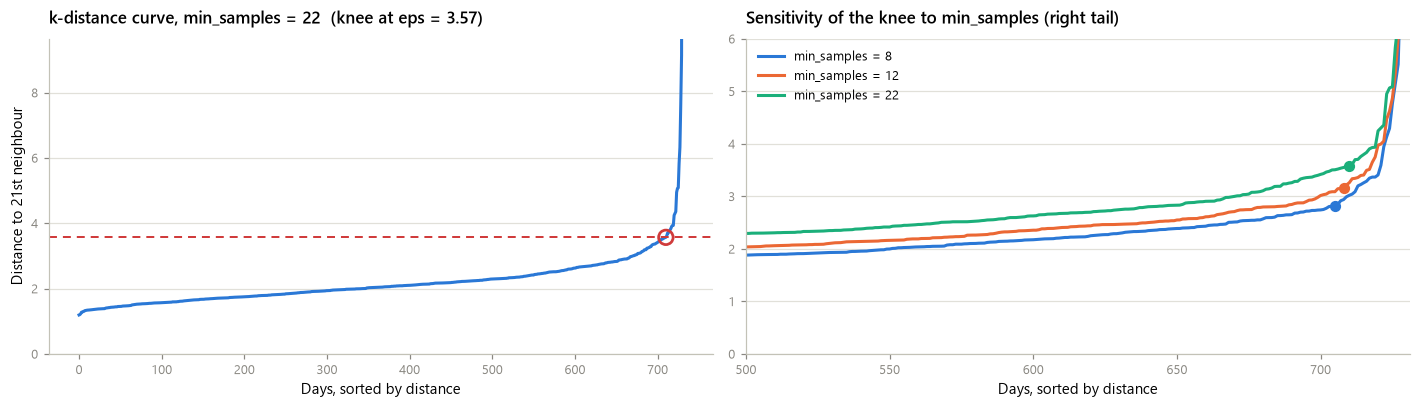

Knee by min_samples: {5: 2.78, 8: 2.82, 12: 3.16, 16: 3.47, 22: 3.57, 30: 3.88}


In [44]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

MIN_SAMPLES = 2 * X.shape[1]


def k_distance(data, min_samples):
    nn = NearestNeighbors(n_neighbors=min_samples).fit(data)
    return np.sort(nn.kneighbors(data)[0][:, -1])


def knee_of(curve):
    x = np.arange(len(curve), dtype=float)
    xn, yn = (x - x.min()) / np.ptp(x), (curve - curve.min()) / np.ptp(curve)
    d = (np.abs((xn[-1] - xn[0]) * (yn[0] - yn) - (xn[0] - xn) * (yn[-1] - yn[0]))
         / np.hypot(xn[-1] - xn[0], yn[-1] - yn[0]))
    return int(d.argmax()), float(curve[d.argmax()])


MS_GRID = [5, 8, 12, 16, 22, 30]
knees = {ms: knee_of(k_distance(X, ms))[1] for ms in MS_GRID}
EPS_KNEE = round(knees[MIN_SAMPLES], 2)

curve = k_distance(X, MIN_SAMPLES)
idx, val = knee_of(curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(np.arange(len(curve)), curve, color=BLUE)
axes[0].axhline(val, color=RED, lw=1.3, ls=(0, (4, 3)))
axes[0].scatter([idx], [val], s=90, facecolor="none", edgecolor=RED, linewidths=1.8, zorder=5)
axes[0].set_ylim(0, np.percentile(curve, 99.6) * 1.5)
axes[0].set_title(f"k-distance curve, min_samples = {MIN_SAMPLES}  (knee at eps = {val:.2f})")
axes[0].set_xlabel("Days, sorted by distance"); axes[0].set_ylabel("Distance to 21st neighbour")
axes[0].xaxis.grid(False)

for ms, colour in zip([8, 12, 22], [BLUE, ORANGE, AQUA]):
    c_ = k_distance(X, ms)
    axes[1].plot(np.arange(len(c_)), c_, color=colour, label=f"min_samples = {ms}")
    axes[1].scatter([knee_of(c_)[0]], [knee_of(c_)[1]], s=40, color=colour, zorder=5)
axes[1].set_xlim(500, 731); axes[1].set_ylim(0, 6)
axes[1].set_title("Sensitivity of the knee to min_samples (right tail)")
axes[1].set_xlabel("Days, sorted by distance"); axes[1].legend(); axes[1].xaxis.grid(False)
plt.tight_layout(); plt.show()

print("Knee by min_samples:", {ms: round(v, 2) for ms, v in knees.items()})

In [45]:
db = DBSCAN(eps=EPS_KNEE, min_samples=MIN_SAMPLES).fit(X)
db_labels = db.labels_
noise_mask = db_labels == -1
RESULTS[f"DBSCAN (eps={EPS_KNEE}, ms={MIN_SAMPLES})"] = db_labels

print(f"DBSCAN(eps={EPS_KNEE}, min_samples={MIN_SAMPLES})")
print(f"  clusters : {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")
print(f"  noise    : {noise_mask.sum()} ({noise_mask.mean():.1%})")
print(f"  core     : {db.core_sample_indices_.size}")
print(f"  sizes    : {np.bincount(db_labels[~noise_mask]).tolist()}")

DBSCAN(eps=3.57, min_samples=22)
  clusters : 1
  noise    : 8 (1.1%)
  core     : 710
  sizes    : [723]


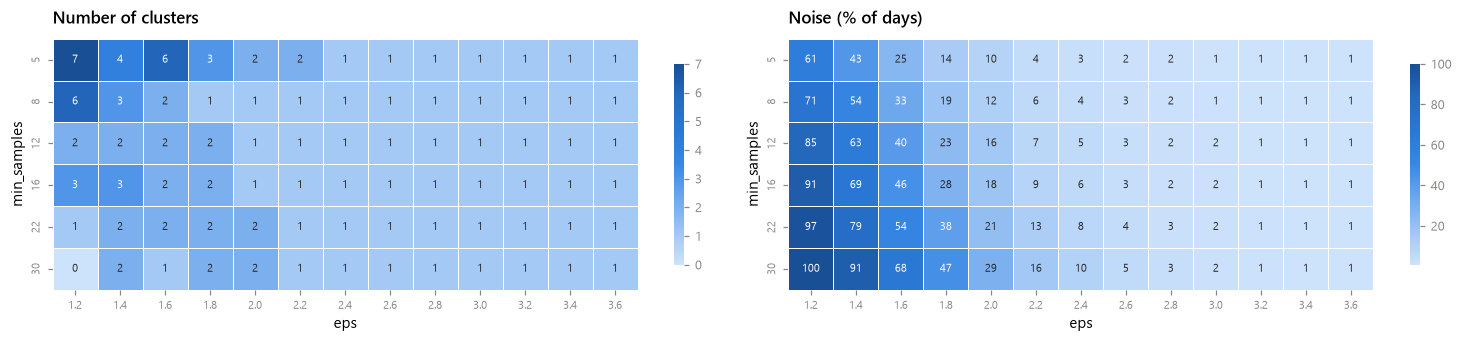

78 settings evaluated.


In [46]:
# Sensitivity across eps and min_samples.
EPS_GRID = np.round(np.arange(1.2, 3.61, 0.2), 2)
grid_rows = []
for ms in MS_GRID:
    for eps in EPS_GRID:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        nz = lab == -1
        grid_rows.append(dict(min_samples=ms, eps=eps,
                              n_clusters=len(set(lab)) - (1 if -1 in lab else 0),
                              noise_pct=100 * nz.mean()))
db_grid = pd.DataFrame(grid_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
for ax, (col, ttl, cmap) in zip(axes, [("n_clusters", "Number of clusters", SEQ),
                                       ("noise_pct", "Noise (% of days)", SEQ)]):
    piv = db_grid.pivot(index="min_samples", columns="eps", values=col)
    sns.heatmap(piv, cmap=cmap, annot=True, fmt=".0f", annot_kws={"size": 7},
                linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(ttl); ax.tick_params(labelsize=7.5); ax.grid(False)
plt.tight_layout(); plt.show()

print(f"{len(db_grid)} settings evaluated.")

In [47]:
SETTINGS = [("Knee (adopted)", MIN_SAMPLES, EPS_KNEE), ("Tighter eps", MIN_SAMPLES, 2.0),
            ("Looser eps", MIN_SAMPLES, 3.0), ("Lower min_samples", 5, 2.0)]
db_variants, rows = {}, []
for name, ms, eps in SETTINGS:
    lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    db_variants[name] = lab
    nz = lab == -1
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    rows.append(dict(setting=name, min_samples=ms, eps=eps, n_clusters=nc,
                     n_noise=int(nz.sum()), noise_pct=round(100 * nz.mean(), 1),
                     sizes=str(sorted(np.bincount(lab[~nz]).tolist(), reverse=True) if nc else []),
                     silhouette=(round(silhouette_score(X[~nz], lab[~nz]), 3) if nc >= 2 else np.nan),
                     ari_vs_kmeans=round(adjusted_rand_score(km_labels, lab), 3)))
RESULTS["DBSCAN (eps=2.0, ms=22)"] = db_variants["Tighter eps"]
pd.DataFrame(rows).set_index("setting")

,min_samples,eps,n_clusters,n_noise,noise_pct,sizes,silhouette,ari_vs_kmeans
setting,,,,,,,,
Knee (adopted),22,3.5700,1,8,1.1000,[723],NaN,0.0030
Tighter eps,22,2.0000,2,155,21.2000,"[419, 157]",0.2930,0.4000
Looser eps,22,3.0000,1,15,2.1000,[716],NaN,0.0070
Lower min_samples,5,2.0000,2,70,9.6000,"[657, 4]",0.2550,0.0390


The output is governed almost entirely by `eps`. There is no stable two-cluster regime with
acceptable noise: forcing a second cluster requires eps = 2.0, which discards 21.2 % of days, and at
min_samples = 5 the second cluster holds only four days.

That is diagnostic rather than a failure. The commuting and leisure groups are separated by a
low-density region rather than an empty one, because enough intermediate days exist (Fridays,
midweek holidays) to keep them density-connected.

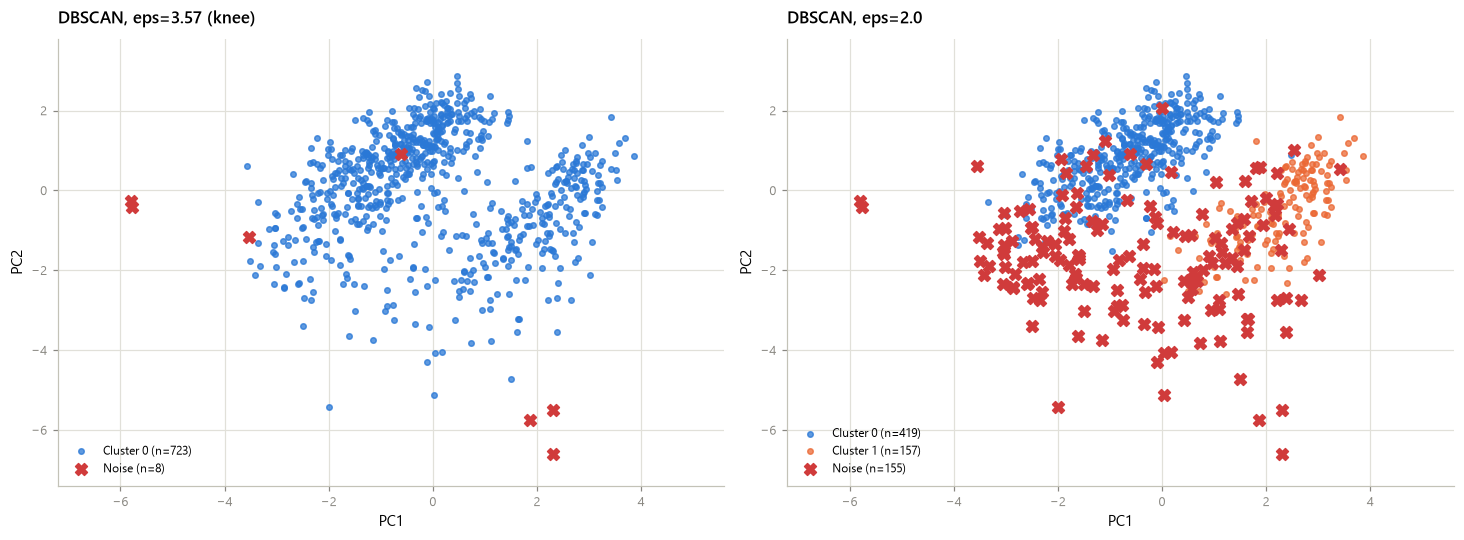

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5))
for ax, (name, lab) in zip(axes, [(f"eps={EPS_KNEE} (knee)", db_labels),
                                  ("eps=2.0", db_variants["Tighter eps"])]):
    nz = lab == -1
    for c in sorted(set(lab[~nz])):
        m = lab == c
        ax.scatter(Z[m, 0], Z[m, 1], s=13, alpha=0.75, color=CLUSTER_COLOURS[c % 4],
                   label=f"Cluster {c} (n={m.sum()})")
    ax.scatter(Z[nz, 0], Z[nz, 1], s=60, marker="X", color=RED, label=f"Noise (n={nz.sum()})")
    ax.set_xlim(-7.2, 5.6); ax.set_ylim(-7.4, 3.8)
    ax.set_title(f"DBSCAN, {name}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

In [49]:
noise_idx = np.flatnonzero(noise_mask)
noise_report = pd.DataFrame({
    "day": [context.index[i].strftime("%Y-%m-%d") for i in noise_idx],
    "weekday": [context.day_name.iloc[i][:3] for i in noise_idx],
    "hours_recorded": [context.observed_hours.iloc[i] for i in noise_idx],
    "quality_flag": [str(context.quality_flag.iloc[i]) for i in noise_idx],
    "rentals": [int(daily.total_rentals.iloc[i]) for i in noise_idx],
    "bad_weather": [round(daily.bad_weather_share.iloc[i], 2) for i in noise_idx],
    "rentals_pctile": [round((daily.total_rentals < daily.total_rentals.iloc[i]).mean() * 100, 1)
                       for i in noise_idx]}).set_index("day")

print("The one genuine data error found in 1.1 was 2011-03-10 (stuck humidity sensor, repaired).")
print("Flagged as noise?", bool(noise_mask[daily.index.get_loc(pd.Timestamp("2011-03-10"))]))
noise_report

The one genuine data error found in 1.1 was 2011-03-10 (stuck humidity sensor, repaired).
Flagged as noise? False


,weekday,hours_recorded,quality_flag,rentals,bad_weather,rentals_pctile
day,,,,,,
2011-01-18,Tue,12,severely_incomplete,683,0.0000,1.0000
2011-01-27,Thu,8,severely_incomplete,431,0.0000,0.1000
2011-03-06,Sun,23,minor_gaps,605,0.3900,0.5000
2011-08-27,Sat,18,severely_incomplete,1115,0.3900,3.7000
2011-08-28,Sun,17,severely_incomplete,4334,0.1200,45.4000
2012-04-22,Sun,24,complete,1027,0.7100,3.0000
2012-10-29,Mon,1,severely_incomplete,22,1.0000,0.0000
2012-10-30,Tue,11,severely_incomplete,1096,0.5500,3.1000


All eight are genuinely unusual mobility days and none is a data error. Six are the storm days from
1.1: their records are short because the service stopped running, not because data was lost. The
other two are severe-weather Sundays with near-complete or complete records; 2012-04-22 has all 24
hours recorded, 17 of them with precipitation, and sits in the 3rd percentile of daily rentals.

The data error that did exist was repaired during cleaning, so its feature vector is now
unremarkable and DBSCAN does not flag it. Data-quality problems belong to the cleaning stage;
unusual but valid days belong to the analysis.

Note on scoring: silhouette and Davies-Bouldin are undefined for a noise "cluster", so DBSCAN is
scored on its clustered points only throughout Part 3, with the excluded count reported alongside.


# Part 3. Evaluation and comparison

Six results are evaluated on silhouette, Davies-Bouldin, intra- and inter-cluster distance, and
cluster size distribution. The degenerate results are kept in the table rather than dropped,
because they are the clearest evidence that no single index is sufficient.

In [50]:
DIST = squareform(pdist(X, metric="euclidean"))
storm_all = storm.to_numpy()


def evaluate_partition(labels, exclude_noise=True):
    labels = np.asarray(labels)
    is_noise = labels == -1
    keep_m = ~is_noise if exclude_noise else np.ones(len(labels), bool)
    L, Xk = labels[keep_m], X[keep_m]
    Dk = DIST[np.ix_(keep_m, keep_m)]
    ks_ = np.unique(L)

    res = {"n_clusters": len(ks_), "n_noise": int(is_noise.sum()), "n_scored": int(keep_m.sum())}
    if len(ks_) < 2:
        res.update({m: np.nan for m in ["silhouette", "davies_bouldin", "intra_mean",
                                        "inter_mean", "min_gap", "separation_ratio",
                                        "size_entropy"]})
        res["sizes"] = np.bincount(L).tolist()
        return res

    res["silhouette"] = silhouette_score(Xk, L)
    res["davies_bouldin"] = davies_bouldin_score(Xk, L)

    intra, centroids_, sizes = [], [], []
    for k in ks_:
        idx = np.flatnonzero(L == k)
        sizes.append(len(idx)); centroids_.append(Xk[idx].mean(axis=0))
        sub = Dk[np.ix_(idx, idx)]
        intra.append(sub[np.triu_indices(len(idx), 1)].mean() if len(idx) > 1 else 0.0)
    centroids_, sizes = np.array(centroids_), np.array(sizes)
    CD = cdist(centroids_, centroids_)
    upper = np.triu_indices(len(ks_), 1)

    res["intra_mean"] = float(np.average(intra, weights=sizes))
    res["inter_mean"] = float(CD[upper].mean())
    res["min_gap"] = float(CD[upper].min())
    # The closest gap is used rather than the mean, which would reward simply having more clusters.
    res["separation_ratio"] = res["min_gap"] / res["intra_mean"]
    pr = sizes / sizes.sum()
    res["size_entropy"] = float(-(pr * np.log(pr)).sum() / np.log(len(ks_)))
    res["sizes"] = sizes.tolist()
    return res


evaluation = pd.DataFrame({n: evaluate_partition(l) for n, l in RESULTS.items()}).T
evaluation[["n_clusters", "n_noise", "n_scored", "silhouette", "davies_bouldin",
            "intra_mean", "min_gap", "separation_ratio", "size_entropy"]].astype(float).round(3)

,n_clusters,n_noise,n_scored,silhouette,davies_bouldin,intra_mean,min_gap,separation_ratio,size_entropy
K-Means (k=5),5.0000,0.0000,731.0000,0.1990,1.2800,3.2600,2.6200,0.8040,0.8450
AGNES single (k=6),6.0000,0.0000,731.0000,0.3120,0.4110,4.1980,4.7350,1.1280,0.0340
AGNES complete (k=6),6.0000,0.0000,731.0000,0.1470,1.2630,3.5220,2.6360,0.7480,0.6460
AGNES average (k=6),6.0000,0.0000,731.0000,0.2740,0.7500,4.1650,5.1820,1.2440,0.0640
"DBSCAN (eps=3.57, ms=22)",1.0000,8.0000,723.0000,NaN,NaN,NaN,NaN,NaN,NaN
"DBSCAN (eps=2.0, ms=22)",2.0000,155.0000,576.0000,0.2930,1.4160,3.2240,3.2360,1.0040,0.8450


Ranked by silhouette alone the two worst clusterings occupy first and third place, and AGNES single
linkage leads on silhouette and Davies-Bouldin simultaneously while placing 725 of 731 days in one
group. The separation ratio does not detect this either, because the gap from a large blob to an
isolated point genuinely is large relative to the blob's internal spread.

Only cluster size distribution is decisive: normalised entropy of 0.034 and 0.064 for the degenerate
results, against 0.845 for K-Means. Four criteria were needed to reach a conclusion that any one
alone would have got wrong.

In [51]:
print("The same DBSCAN result under the two possible noise conventions:\n")
for name in [n for n in RESULTS if n.startswith("DBSCAN")]:
    lab = np.asarray(RESULTS[name])
    excl = evaluate_partition(lab, True)
    incl = evaluate_partition(lab, False) if len(np.unique(lab)) >= 2 else {"silhouette": np.nan}
    print(f"  {name}: noise excluded {excl['silhouette'] if excl['silhouette'] == excl['silhouette'] else 'undefined'}"
          f"   noise as a cluster {incl['silhouette']:.3f}")
print("\nAt the knee setting, counting noise as a cluster gives 0.588, the highest silhouette")
print("anywhere in this study, for a result with one real cluster.")

The same DBSCAN result under the two possible noise conventions:

  DBSCAN (eps=3.57, ms=22): noise excluded undefined   noise as a cluster 0.588
  DBSCAN (eps=2.0, ms=22): noise excluded 0.293265125687032   noise as a cluster 0.199

At the knee setting, counting noise as a cluster gives 0.588, the highest silhouette
anywhere in this study, for a result with one real cluster.


In [52]:
# Parameter sensitivity and resampling stability, measured comparably across the three methods.
Z_complete = Zs["complete"]
base = {"K-Means (k=5)": km_labels, "AGNES complete (k=6)": agnes_labels,
        "DBSCAN (eps=2.0, ms=22)": np.asarray(RESULTS["DBSCAN (eps=2.0, ms=22)"])}

perturb = []
for kk in (4, 6):
    perturb.append(("K-Means (k=5)", f"k={kk}", adjusted_rand_score(
        base["K-Means (k=5)"], KMeans(kk, n_init=50, random_state=RANDOM_STATE).fit_predict(X))))
for kk in (5, 7):
    perturb.append(("AGNES complete (k=6)", f"k={kk}", adjusted_rand_score(
        base["AGNES complete (k=6)"], fcluster(Z_complete, kk, criterion="maxclust"))))
for f in (0.9, 1.1):
    perturb.append(("DBSCAN (eps=2.0, ms=22)", f"eps={2.0 * f:.2f}", adjusted_rand_score(
        base["DBSCAN (eps=2.0, ms=22)"],
        DBSCAN(eps=2.0 * f, min_samples=MIN_SAMPLES).fit_predict(X))))
perturb = pd.DataFrame(perturb, columns=["method", "perturbation", "ARI_vs_base"])

rng = np.random.default_rng(RANDOM_STATE)
fitters = {
    "K-Means (k=5)": lambda A: KMeans(5, n_init=20, random_state=1).fit_predict(A),
    "AGNES complete (k=6)": lambda A: fcluster(linkage(pdist(A), "complete"), 6, "maxclust"),
    "DBSCAN (eps=2.0, ms=22)": lambda A: DBSCAN(eps=2.0, min_samples=MIN_SAMPLES).fit_predict(A)}
stab_rows = {}
for name, fit in fitters.items():
    sc = []
    for _ in range(30):
        idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
        sc.append(adjusted_rand_score(np.asarray(base[name])[idx], fit(X[idx])))
    stab_rows[name] = (float(np.mean(sc)), float(np.std(sc)))

stability_tbl = pd.DataFrame(stab_rows, index=["resample_ARI_mean", "sd"]).T
stability_tbl["worst_perturbation_ARI"] = perturb.groupby("method").ARI_vs_base.min()
print(perturb.round(3).to_string(index=False), "\n")
stability_tbl.round(3)

                 method perturbation  ARI_vs_base
          K-Means (k=5)          k=4       0.7100
          K-Means (k=5)          k=6       0.7700
   AGNES complete (k=6)          k=5       0.7350
   AGNES complete (k=6)          k=7       0.9950
DBSCAN (eps=2.0, ms=22)     eps=1.80       0.6480
DBSCAN (eps=2.0, ms=22)     eps=2.20       0.2660 



,resample_ARI_mean,sd,worst_perturbation_ARI
K-Means (k=5),0.8960,0.0920,0.7100
AGNES complete (k=6),0.3340,0.1260,0.7350
"DBSCAN (eps=2.0, ms=22)",0.8740,0.0230,0.2660


In [53]:
# How each result treats the eight storm days.
unusual = []
for name, lab in RESULTS.items():
    lab = np.asarray(lab)
    sizes = pd.Series(lab).value_counts()
    sl = lab[storm_all]
    as_noise = int((sl == -1).sum())
    isolated = sum(1 for l in sl if l == -1 or sizes.get(l, 0) <= 3)
    m = lab != -1
    unusual.append({"result": name, "as_noise": as_noise,
                    "in_micro_cluster": isolated - as_noise,
                    "absorbed": 8 - isolated,
                    "ARI_vs_workingday": round(adjusted_rand_score(context.workingday[m], lab[m]), 3)})
pd.DataFrame(unusual).set_index("result")

,as_noise,in_micro_cluster,absorbed,ARI_vs_workingday
result,,,,
K-Means (k=5),0,1,7,0.3760
AGNES single (k=6),0,6,2,0.0000
AGNES complete (k=6),0,3,5,0.3710
AGNES average (k=6),0,6,2,0.0180
"DBSCAN (eps=3.57, ms=22)",6,0,2,0.0000
"DBSCAN (eps=2.0, ms=22)",8,0,0,0.9500


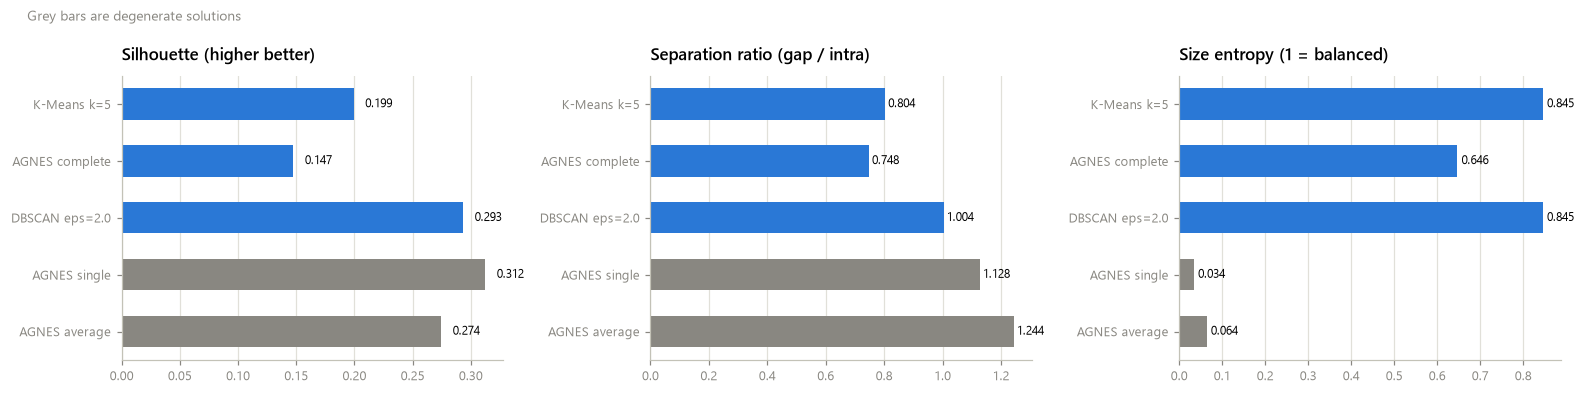

In [54]:
meaningful = ["K-Means (k=5)", "AGNES complete (k=6)", "DBSCAN (eps=2.0, ms=22)"]
degenerate = ["AGNES single (k=6)", "AGNES average (k=6)"]
plot_order = meaningful + degenerate
short = {"K-Means (k=5)": "K-Means k=5", "AGNES complete (k=6)": "AGNES complete",
         "DBSCAN (eps=2.0, ms=22)": "DBSCAN eps=2.0",
         "AGNES single (k=6)": "AGNES single", "AGNES average (k=6)": "AGNES average"}
face = [BLUE] * 3 + [MUTED] * 2
y = np.arange(len(plot_order))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
for ax, (col, ttl) in zip(axes, [("silhouette", "Silhouette (higher better)"),
                                 ("separation_ratio", "Separation ratio (gap / intra)"),
                                 ("size_entropy", "Size entropy (1 = balanced)")]):
    v = evaluation.loc[plot_order, col].astype(float).to_numpy()
    ax.barh(y, v, height=0.55, color=face)
    for yi, val_ in zip(y, v):
        ax.text(val_ + 0.01, yi, f"{val_:.3f}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([short[m] for m in plot_order], fontsize=8.5)
    ax.invert_yaxis(); ax.set_title(ttl); ax.yaxis.grid(False)
plt.suptitle("Grey bars are degenerate solutions", x=0.02, ha="left", fontsize=9, color=MUTED)
plt.tight_layout(); plt.show()

### Comparison on the six required criteria

**Separation.** No method achieves strong separation, consistent with the continuum found in 1.4.
DBSCAN's single gap is widest but was produced by deleting the 155 days lying between its clusters.
K-Means (2.62) and AGNES complete (2.64) are near-identical.

**Compactness.** K-Means is tightest of the solutions scored on all 731 days (3.26 against a
dataset mean of 4.34), which is expected since minimising within-cluster variance is its objective.

**Parameter sensitivity.** Under a one-step parameter change K-Means retains ARI 0.71 and 0.77 and
AGNES 0.74 and 0.99, while DBSCAN collapses to 0.27 when eps rises 10 %. Under 80 % resampling
K-Means scores 0.896 and DBSCAN 0.874, but AGNES complete only 0.334: complete linkage merges on
diameter, which is set by extreme points, so removing a fifth of the days reorganises the tree.

**Size balance.** K-Means and DBSCAN both reach 0.845, AGNES complete 0.646, the degenerate results
0.034 and 0.064.

**Interpretability.** K-Means gives four operationally distinct regimes, AGNES complete four
comparable ones but with two micro-clusters, DBSCAN only two covering 79 % of days. DBSCAN's ARI of
0.950 against the working/non-working split looks dominant but is inflated: it discarded the
ambiguous days, so the split of what remains is nearly trivial.

**Treatment of unusual observations.** DBSCAN is clearly best, labelling all eight storm days noise
at eps = 2.0. K-Means is worst, absorbing seven and spending a cluster on the eighth.

### Selection

**K-Means with k = 5 is selected.** It does not lead on any single index and is not chosen as though
it did: its silhouette of 0.199 ranks fourth of five. It is best on compactness, stability, size
balance and interpretability, and comparable on separation.

AGNES single and average are excluded on size distribution alone. AGNES complete is a close second
recovering similar structure, but a resampling agreement of 0.334 means a different sample would
give a substantially different partition. DBSCAN at the knee returns one cluster; at eps = 2.0 it
discards 21 % of days, collapses under a 10 % change in eps, and two clusters cannot distinguish
high- from low-demand commuting days.

The known weakness is carried forward rather than hidden. Part 4 profiles the four substantive
clusters and treats C4 as a flagged anomaly, using DBSCAN's noise set as the authority on
exceptional days.

---
# Part 4. Cluster interpretation and validation

Profiles use original, non-standardised features. The calendar and weather attributes below were
withheld from the clustering, so agreement with them is genuine external validation.

In [55]:
PART4 = km_labels < 4
p4 = km_labels[PART4]
print(f"Profiling {PART4.sum()} of {len(km_labels)} days "
      f"(cluster 4, Hurricane Sandy, held out as an anomaly)")

profile_orig = daily[PART4].groupby(p4).mean().T
profile_orig.columns = [f"C{c}" for c in range(4)]
profile_orig["All days"] = daily[PART4].mean()
profile_orig.round(3)

Profiling 730 of 731 days (cluster 4, Hurricane Sandy, held out as an anomaly)


,C0,C1,C2,C3,All days
total_rentals,"5,867.1620","4,515.9520","3,448.8400","3,094.5920","4,510.4890"
mean_hourly_rentals,244.4650,188.1650,143.7020,128.9410,187.9370
max_hourly_rentals,690.5550,424.6390,423.0000,405.2720,510.9600
std_hourly_rentals,195.5720,142.4180,119.1990,110.8570,150.2280
morning_peak_share,0.1810,0.0360,0.1870,0.1850,0.1420
evening_peak_share,0.2890,0.2150,0.2820,0.2620,0.2620
offpeak_share,0.5300,0.7490,0.5300,0.5530,0.5960
night_share,0.0210,0.0630,0.0190,0.0300,0.0340
midday_share,0.2040,0.4210,0.2190,0.2190,0.2720
peak_to_mean_ratio,2.8320,2.3440,2.9820,3.1660,2.7810


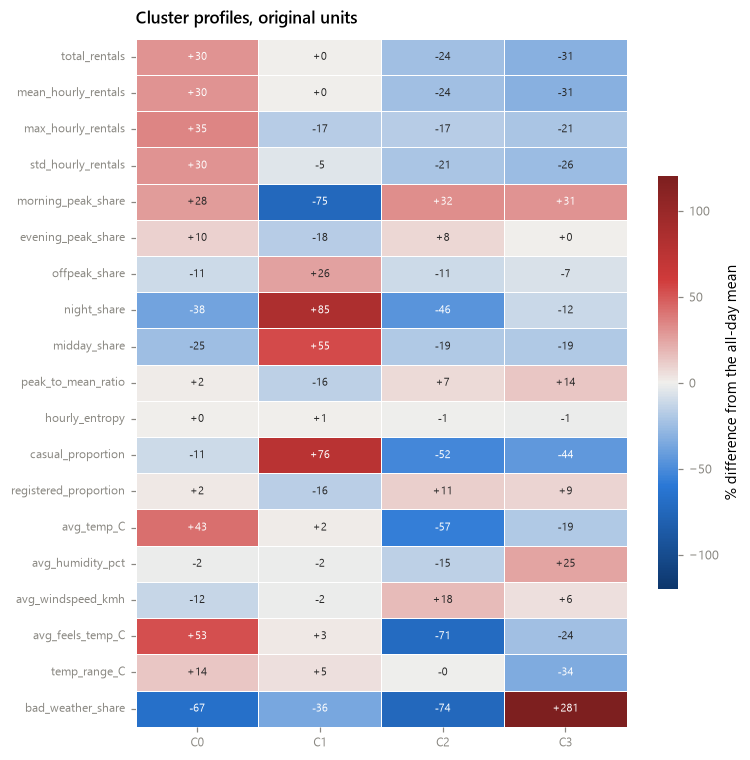

In [56]:
dev = (profile_orig[[f"C{c}" for c in range(4)]]
       .sub(profile_orig["All days"], axis=0)
       .div(profile_orig["All days"].abs(), axis=0) * 100)

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(dev, cmap=DIV, center=0, vmin=-120, vmax=120, annot=True, fmt="+.0f",
            annot_kws={"size": 7.5}, linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"shrink": 0.6, "label": "% difference from the all-day mean"})
ax.set_title("Cluster profiles, original units"); ax.tick_params(labelsize=8); ax.grid(False)
plt.tight_layout(); plt.show()

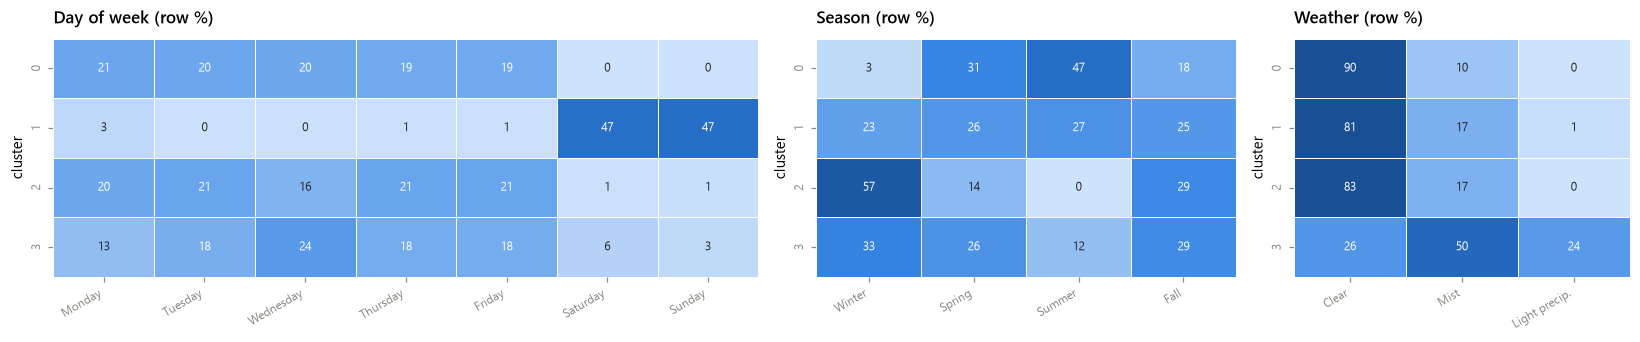

,name,days,weekend %,holidays,working day %,2012 %
0,High-demand warm-season commuting,247,0.4000,3,98.4000,55.9000
1,Weekend and holiday leisure,208,93.8000,11,1.0000,50.0000
2,Cold-season clear-weather commuting,150,2.0000,5,94.7000,48.7000
3,Adverse-weather suppressed demand,125,8.8000,2,89.6000,40.0000


In [57]:
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
ctx4 = context[PART4].copy(); ctx4["cluster"] = p4

weekday_pct = (pd.crosstab(ctx4.cluster, ctx4.day_name, normalize="index")[DAYS] * 100).round(1)
season_pct = (pd.crosstab(ctx4.cluster, ctx4.season_name,
                          normalize="index")[["Winter", "Spring", "Summer", "Fall"]] * 100).round(1)
weather_pct = (pd.crosstab(ctx4.cluster, ctx4.weather_name,
                           normalize="index")[["Clear", "Mist", "Light precip."]] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2), gridspec_kw={"width_ratios": [2.1, 1.25, 1]})
for ax, tbl, ttl in [(axes[0], weekday_pct, "Day of week"), (axes[1], season_pct, "Season"),
                     (axes[2], weather_pct, "Weather")]:
    sns.heatmap(tbl, cmap=SEQ, vmin=0, vmax=60, annot=True, fmt=".0f", annot_kws={"size": 8},
                linewidths=0.5, linecolor="white", ax=ax, cbar=False)
    ax.set_title(f"{ttl} (row %)"); ax.set_xlabel(""); ax.tick_params(labelsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right"); ax.grid(False)
plt.tight_layout(); plt.show()

pd.DataFrame({
    "name": pd.Series({c: CLUSTER_NAMES[c] for c in range(4)}),
    "days": np.bincount(p4),
    "weekend %": (ctx4.groupby("cluster").is_weekend.mean() * 100).round(1),
    "holidays": ctx4.groupby("cluster").holiday.sum(),
    "working day %": (ctx4.groupby("cluster").workingday.mean() * 100).round(1),
    "2012 %": (ctx4.groupby("cluster").yr.mean() * 100).round(1)})

The weekday split is recovered almost perfectly: C1 holds 92.4 % of all Saturdays and 93.3 % of all
Sundays and is 99 % non-working, while the three commuting clusters are 89-98 % working days. C0 is
47 % summer and 3 % winter, C2 is 57 % winter with no summer day at all, and C3 holds 30 of the
dataset's 33 light-precipitation days.

One result is not a confirmation. Of the 21 public holidays, eleven fall in the leisure cluster but
ten fall in commuting clusters, so the holiday flag alone is a poor predictor of behaviour. That is
only visible because the calendar was withheld.

No cluster is dominated by a single year (the largest imbalance is 60/40), so the volume-based
C0/C2 split reflects season and weather rather than the 64 % growth between 2011 and 2012.

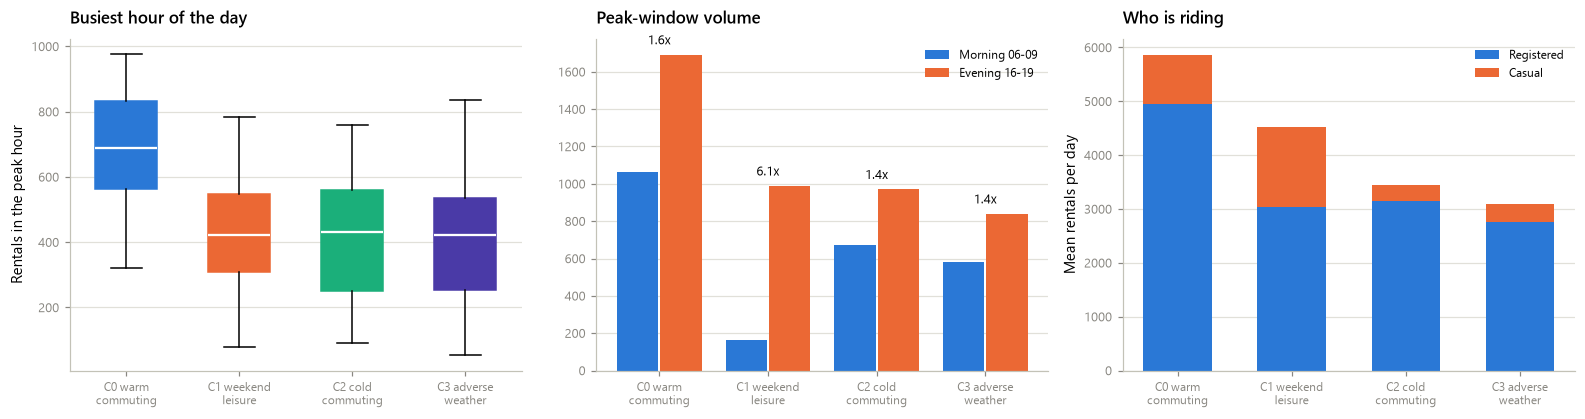

    morning 06-09  evening 16-19  evening:morning  registered/day  casual/day
C0     1,064.0000     1,692.0000           1.5900      4,953.0000    914.0000
C1       163.0000       989.0000           6.0900      3,036.0000  1,480.0000
C2       671.0000       971.0000           1.4500      3,147.0000    302.0000
C3       584.0000       840.0000           1.4400      2,766.0000    329.0000


In [58]:
cnt_all = hourly["cnt"].unstack("hr")
morning_vol = cnt_all[MORNING_PEAK].sum(axis=1)[PART4]
evening_vol = cnt_all[EVENING_PEAK].sum(axis=1)[PART4]
casual_vol = (daily.casual_proportion * daily.total_rentals)[PART4]
reg_vol = (daily.registered_proportion * daily.total_rentals)[PART4]
names_short = ["C0 warm\ncommuting", "C1 weekend\nleisure", "C2 cold\ncommuting", "C3 adverse\nweather"]
xc = np.arange(4)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
bp = axes[0].boxplot([daily.max_hourly_rentals[PART4][p4 == c] for c in range(4)],
                     patch_artist=True, widths=0.55,
                     medianprops=dict(color="white", linewidth=1.5),
                     flierprops=dict(marker="o", markersize=3, markeredgecolor="none", alpha=0.4))
for patch, colour in zip(bp["boxes"], CLUSTER_COLOURS):
    patch.set_facecolor(colour); patch.set_edgecolor(colour)
axes[0].set_xticks(range(1, 5)); axes[0].set_xticklabels(names_short, fontsize=8)
axes[0].set_title("Busiest hour of the day"); axes[0].set_ylabel("Rentals in the peak hour")

mv = [morning_vol[p4 == c].mean() for c in range(4)]
ev = [evening_vol[p4 == c].mean() for c in range(4)]
axes[1].bar(xc - 0.2, mv, width=0.38, color=BLUE, label="Morning 06-09")
axes[1].bar(xc + 0.2, ev, width=0.38, color=ORANGE, label="Evening 16-19")
for i, (a, b) in enumerate(zip(mv, ev)):
    axes[1].text(i, max(a, b) + 55, f"{b / a:.1f}x", ha="center", fontsize=8.5)
axes[1].set_xticks(xc); axes[1].set_xticklabels(names_short, fontsize=8)
axes[1].set_title("Peak-window volume"); axes[1].legend(fontsize=8)

rv = [reg_vol[p4 == c].mean() for c in range(4)]
cv = [casual_vol[p4 == c].mean() for c in range(4)]
axes[2].bar(xc, rv, width=0.6, color=BLUE, label="Registered")
axes[2].bar(xc, cv, width=0.6, bottom=rv, color=ORANGE, label="Casual")
axes[2].set_xticks(xc); axes[2].set_xticklabels(names_short, fontsize=8)
axes[2].set_title("Who is riding"); axes[2].set_ylabel("Mean rentals per day"); axes[2].legend(fontsize=8)
for ax in axes:
    ax.xaxis.grid(False)
plt.tight_layout(); plt.show()

print(pd.DataFrame({"morning 06-09": np.round(mv, 0), "evening 16-19": np.round(ev, 0),
                    "evening:morning": np.round(np.array(ev) / np.array(mv), 2),
                    "registered/day": np.round(rv, 0), "casual/day": np.round(cv, 0)},
                   index=[f"C{c}" for c in range(4)]))

### Mobility behaviour

**C0, high-demand warm-season commuting (247 days).** The system at capacity: 1,064 rentals in the
morning window and 1,692 in the evening, with the busiest hour averaging 691 and reaching 977.
Commuting plus a discretionary overlay of 914 casual rentals a day.

**C1, weekend and holiday leisure (208 days).** The morning window carries 163 rentals against C0's
1,064, a 6.5-fold difference, and demand forms a single 11:00-16:00 plateau. Casual riders supply
1,480 rentals a day, the highest of any cluster. Total demand is not low at 4,516 a day: these are
busy days that are busy at different hours, serving a different population.

**C2, cold-season clear-weather commuting (150 days).** Behaviourally identical to C0 at 59 % of the
volume. The difference is who disappears: registered demand falls 36 % while casual demand falls
67 %, taking the casual share to 8.5 %, the lowest of any cluster.

**C3, adverse-weather suppressed demand (125 days).** Working days keeping the commuting shape but
with demand suppressed, humidity at 78.3 % and an adverse-weather share twelve times C0's. The
temperature range is compressed to 5.4 C, the signature of unbroken overcast rather than a passing
shower. Unlike C2 it occurs in all four seasons.

Across the four regimes registered demand varies by a factor of 1.8 while casual demand varies by
4.9, so essentially all variance in total daily demand is casual-rider variance.

In [59]:
# Is the regime predictable from information available the previous evening?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

forecast_features = pd.DataFrame({
    "forecast_temp_C": daily.avg_temp_C, "forecast_humidity": daily.avg_humidity_pct,
    "forecast_wind": daily.avg_windspeed_kmh, "forecast_bad_weather": daily.bad_weather_share,
    "forecast_temp_range": daily.temp_range_C, "is_working_day": context.workingday,
    "day_of_week": context.weekday, "season": context.season,
    "is_holiday": context.holiday})[PART4]

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
clf = RandomForestClassifier(400, random_state=RANDOM_STATE)
acc = cross_val_score(clf, forecast_features, p4, cv=cv)
acc_weather = cross_val_score(
    clf, forecast_features.drop(columns=["is_working_day", "day_of_week", "is_holiday"]), p4, cv=cv)

print(f"Forecast + calendar : {acc.mean():.1%} (sd {acc.std():.1%})")
print(f"Weather only        : {acc_weather.mean():.1%}")
print(f"Majority baseline   : {pd.Series(p4).value_counts(normalize=True).max():.1%}\n")
print(pd.Series(clf.fit(forecast_features, p4).feature_importances_,
                index=forecast_features.columns).sort_values(ascending=False).round(3).to_string())

Forecast + calendar : 91.6% (sd 0.7%)
Weather only        : 62.9%
Majority baseline   : 33.8%

is_working_day         0.2580
forecast_temp_C        0.2150
forecast_bad_weather   0.1420
day_of_week            0.1150
forecast_humidity      0.0960
forecast_wind          0.0640
forecast_temp_range    0.0610
season                 0.0420
is_holiday             0.0080


In [60]:
capacity = pd.DataFrame({
    "days": np.bincount(p4),
    "mean peak hour": daily.max_hourly_rentals[PART4].groupby(p4).mean().round(0).to_numpy(),
    "p90 peak hour": daily.max_hourly_rentals[PART4].groupby(p4).quantile(0.9).round(0).to_numpy(),
    "mean rentals": daily.total_rentals[PART4].groupby(p4).mean().round(0).to_numpy(),
    "days below 2,000": [int((daily.total_rentals[PART4][p4 == c] < 2000).sum()) for c in range(4)],
}, index=[f"C{c}" for c in range(4)])
capacity["spare vs C0 p90"] = (capacity.loc["C0", "p90 peak hour"]
                               - capacity["p90 peak hour"]).astype(int)
capacity

,days,mean peak hour,p90 peak hour,mean rentals,"days below 2,000",spare vs C0 p90
C0,247,691.0000,890.0000,"5,867.0000",0,0
C1,208,425.0000,656.0000,"4,516.0000",27,234
C2,150,423.0000,680.0000,"3,449.0000",36,210
C3,125,405.0000,669.0000,"3,095.0000",34,221


### Practical insights

**1. Size the fleet for one regime, not the average.** The busiest hour averages 691 rentals in C0
and reaches 977, against 405-425 elsewhere; at the 90th percentile the gap is 890 against 656-680.
Provisioning uniformly for C0 leaves roughly 222 bikes per hour idle on the other 483 days. A
reserve tranche deployed only on forecast-C0 days converts that into maintenance throughput without
reducing peak service.

**2. Rebalancing should switch mode, not just scale.** The evening-to-morning ratio is 1.59, 1.45
and 1.44 for the commuting regimes but 6.07 for leisure days, where the morning window carries only
163 rentals. Commuting days present a directional problem, reversing morning accumulation before the
larger evening peak. Leisure days have no morning surge to reverse and instead need continuous
low-intensity redistribution through 11:00-16:00. These are different operations.

**3. Maintenance windows are predictable.** 97 days fall below 2,000 rentals (36 in C2, 34 in C3, 27
in C1, none in C0), 13.3 % of the year. C2 concentrates in January, February and December, but C3
occurs in all four seasons, so an adverse-weather day in June is also a legitimate slot that a
season-based rule would miss.

**4. The regime is forecastable a day ahead** at 91.6 % accuracy against a 33.8 % baseline, using
only a weather forecast and the calendar. This is what makes the other three actionable: a four-way
classification is a far more robust target than a continuous rental count.

These are system-wide daily insights. The dataset holds no station-level data, so insight 2
identifies the type and timing of the operation required but not which stations to service.


## Reproducibility notes

- Single seed `RANDOM_STATE = 42` for K-Means initialisation, t-SNE, PCA, the random-forest check
  and all resampling. Library versions are printed in section 0.
- Cleaning: 165 unrecorded hours inserted as zero-rental hours; 22 zero-humidity readings on
  2011-03-10 imputed from the same clock hour on adjacent days; all eight storm days retained.
- Transformations: cube root on `night_share`, `bad_weather_share` and `casual_proportion`;
  z-score standardisation of the final 11 features.
- Removed features: `mean_hourly_rentals`, `offpeak_share`, `registered_proportion` (algebraic
  identities); `avg_feels_temp_C`, `std_hourly_rentals`, `max_hourly_rentals`, `peak_to_mean_ratio`,
  `midday_share` (collinearity, pruned to VIF < 5).
- Clustering parameters: K-Means k = 5, `n_init` = 50; AGNES complete linkage cut at k = 6;
  DBSCAN `eps` = 3.57 with `min_samples` = 22 at the knee, and `eps` = 2.0 as the two-cluster
  alternative.
- No observation was removed at any stage, and none to improve a clustering score.